# NB06 — Aggregate Statistics and Final Figures

Merges the independent training runs from NB03 and NB04, runs Friedman and
Bonferroni-corrected Wilcoxon significance tests on the resulting genuinely
independent runs (with an explicit statistical-power caveat when the number of seeds
is small), redraws every figure in one consistent, explicitly specified matplotlib
style, and writes `REVISION_RESULTS.json` and `manuscript_numbers.md` — a single
reference listing every number needed for the manuscript, with prior values shown
alongside the corrected ones for traceability.

Attach the outputs of NB01–NB05 as Kaggle Datasets, then run. CPU only, ≈10 minutes.


In [1]:
import json, numpy as np, pandas as pd, matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap
from pathlib import Path
from scipy.stats import friedmanchisquare, wilcoxon
from itertools import combinations
from sklearn.metrics import f1_score, accuracy_score

# ---- consistent manual style (concern #9) ----
plt.rcParams.update({
 'figure.dpi':150,'savefig.dpi':300,'font.family':'DejaVu Sans','font.size':10,
 'axes.spines.top':False,'axes.spines.right':False,'axes.grid':True,
 'grid.alpha':0.22,'grid.linewidth':0.5,'axes.axisbelow':True,
 'axes.edgecolor':'#666666','axes.linewidth':0.8,
 'axes.titlesize':11,'axes.titleweight':'bold','axes.labelsize':10,
 'legend.frameon':False,'xtick.labelsize':9,'ytick.labelsize':9,
 'pdf.fonttype':42,'ps.fonttype':42})   # TrueType fonts -> editable/embeddable PDF

# ---- LIGHTER palette (same hues, reduced saturation) + darker edge for contrast ----
PAL={'MobileNetV3Large':'#8FAFD4','EfficientNetB0':'#F0B48A','EfficientNetB3':'#93C9A5',
     'ResNet50':'#E29497','ViTBase16':'#B3A8D3'}
# line/marker-edge variants: the same hue at full strength, for curves and outlines
PAL_DK={'MobileNetV3Large':'#4C72B0','EfficientNetB0':'#DD8452','EfficientNetB3':'#55A868',
        'ResNet50':'#C44E52','ViTBase16':'#8172B3'}
NAT={'MobileNetV3Large':'MobileNetV3-L','EfficientNetB0':'EfficientNet-B0',
     'EfficientNetB3':'EfficientNet-B3','ResNet50':'ResNet-50','ViTBase16':'ViT-Base/16'}
COND={'naive':'#E29497','group':'#8FAFD4'}          # light bars
COND_DK={'naive':'#C44E52','group':'#4C72B0'}       # matching outlines

def light_cmap(name, lo=0.0, hi=0.68, n=256):
    """Truncate a matplotlib colormap so the top end stays light enough to
    read black annotation text against."""
    base=plt.get_cmap(name)
    return LinearSegmentedColormap.from_list(f'{name}_lt', base(np.linspace(lo,hi,n)))

CMAP_CM = light_cmap('Blues', 0.0, 0.62)   # confusion matrices
CMAP_F1 = light_cmap('YlGn',  0.0, 0.60)   # per-class F1 heatmap

def save_fig(fig, name):
    """Save every figure as BOTH vector PDF (for LaTeX) and PNG (for previewing).
    `name` is given without an extension."""
    name=str(name).replace('.png','').replace('.pdf','')
    for ext in ('pdf','png'):
        fig.savefig(FIG/f'{name}.{ext}', bbox_inches='tight',
                    pad_inches=0.06, facecolor='white')
    return FIG/f'{name}.pdf'


In [2]:
# ===== Config: attach NB01-NB05 outputs =====
P_SPLITS   = Path('/kaggle/input/datasets/maruf170102/bdlitchi-revision-splits/revision_splits')
P_ABLATION = Path('/kaggle/input/datasets/maruf170102/nb02-result/revision_ablation')
P_CNN      = Path('/kaggle/input/datasets/maruf170102/nb03-result/revision_seeds_cnn')
P_VIT      = Path('/kaggle/input/datasets/maruf170102/nb04-result/revision_seeds_vit')
P_SHORT    = Path('/kaggle/input/datasets/maruf170102/nb05-result/revision_shortcut')
# If NB03/NB04 had to be split across sessions, list the extra output dataset
# folders here and they will be merged in automatically.
EXTRA_RUN_DIRS = [   # e.g. Path('/kaggle/input/bdlitchi-revision-seeds-cnn-part2')
]
OUT_DIR    = Path('/kaggle/working/revision_final'); OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG=OUT_DIR/'figures'; FIG.mkdir(exist_ok=True)

for p in [P_SPLITS,P_ABLATION,P_CNN,P_VIT,P_SHORT]+EXTRA_RUN_DIRS:
    print(('OK   ' if p.exists() else 'MISS '), p)

OK    /kaggle/input/datasets/maruf170102/bdlitchi-revision-splits/revision_splits
OK    /kaggle/input/datasets/maruf170102/nb02-result/revision_ablation
OK    /kaggle/input/datasets/maruf170102/nb03-result/revision_seeds_cnn
OK    /kaggle/input/datasets/maruf170102/nb04-result/revision_seeds_vit
OK    /kaggle/input/datasets/maruf170102/nb05-result/revision_shortcut


In [3]:
# ===== 1. Merge independent runs =====
frames=[]
for p in [P_CNN,P_VIT]+EXTRA_RUN_DIRS:
    f=p/'independent_runs.csv'
    if f.exists(): frames.append(pd.read_csv(f))
runs=pd.concat(frames,ignore_index=True) if frames else pd.DataFrame()
assert len(runs), 'No independent_runs.csv found - run NB03/NB04 first.'
runs['model']=pd.Categorical(runs.model,[m for m in PAL if m in set(runs.model)],ordered=True)
runs=runs.sort_values(['model','seed'])
n_seeds=runs.groupby('model').size()
print('runs per model:\n',n_seeds,'\n')
summ=runs.groupby('model')[['accuracy','f1_macro','mcc']].agg(['mean','std']).round(4)
print(summ)
runs.to_csv(OUT_DIR/'independent_runs_merged.csv',index=False)

runs per model:
 model
MobileNetV3Large    3
EfficientNetB0      3
EfficientNetB3      3
ResNet50            3
ViTBase16           3
dtype: int64 

                 accuracy         f1_macro             mcc        
                     mean     std     mean     std    mean     std
model                                                             
MobileNetV3Large   0.9886  0.0045   0.9890  0.0044  0.9875  0.0050
EfficientNetB0     0.9826  0.0100   0.9831  0.0099  0.9810  0.0109
EfficientNetB3     0.9808  0.0051   0.9817  0.0048  0.9790  0.0057
ResNet50           0.9880  0.0028   0.9883  0.0028  0.9868  0.0030
ViTBase16          0.9117  0.0232   0.9145  0.0226  0.9041  0.0255


/tmp/ipykernel_23/1833005407.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  n_seeds=runs.groupby('model').size()
/tmp/ipykernel_23/1833005407.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summ=runs.groupby('model')[['accuracy','f1_macro','mcc']].agg(['mean','std']).round(4)


In [4]:
# ===== 2. Statistics on INDEPENDENT runs (concern #7) =====
METRIC='f1_macro'
piv=runs.pivot_table(index='seed',columns='model',values=METRIC,observed=True).dropna()
models=list(piv.columns); k=len(models); n=len(piv)
print(f'blocks (seeds) n={n}, models k={k}, metric={METRIC}\n')
print(piv.round(4),'\n')

stats_out={'metric':METRIC,'n_blocks':int(n),'k_models':int(k),
           'evaluation_set':'common_test (specimen-disjoint, never trained on)',
           'note':'Each observation is an INDEPENDENT training run (fresh init + training), '
                  'not a re-scoring of one checkpoint.'}

if n<3:
    print('*** n<3 blocks: Friedman not computable. Report descriptive stats only. ***')
    stats_out['friedman']=None
else:
    chi,pv=friedmanchisquare(*[piv[m].values for m in models])
    stats_out['friedman']={'chi2':float(chi),'df':k-1,'p':float(pv)}
    print(f'Friedman: chi2({k-1}) = {chi:.4f}, p = {pv:.3g}')
    if n<5:
        print('  WARNING: with only %d blocks this test has very low power.' % n)
        print('  A non-significant result here does NOT mean the models are equivalent.')
        stats_out['power_warning']=(f'Only {n} independent runs per model. Low power; '
            'absence of significance must not be reported as evidence of equivalence.')

    pairs=list(combinations(models,2)); m_comp=len(pairs); alpha=0.05/m_comp
    print(f'\nPairwise Wilcoxon, Bonferroni alpha = 0.05/{m_comp} = {alpha:.4g}')
    pw={}
    for a,b in pairs:
        d=piv[a].values-piv[b].values
        if np.allclose(d,0):
            pw[f'{a}_vs_{b}']={'p_raw':None,'p_corrected':None,'note':'degenerate (all differences zero)'}
            print(f'  {NAT[a]:16s} vs {NAT[b]:16s}  degenerate (identical on every run)')
            continue
        try:
            st,p=wilcoxon(piv[a].values,piv[b].values)
            pc=min(1.0,p*m_comp)
            pw[f'{a}_vs_{b}']={'p_raw':float(p),'p_corrected':float(pc),
                               'significant':bool(pc<0.05)}
            print(f'  {NAT[a]:16s} vs {NAT[b]:16s}  p={p:.4g}  p_corr={pc:.4g}'
                  f'{"  *" if pc<0.05 else ""}')
        except Exception as e:
            pw[f'{a}_vs_{b}']={'error':str(e)}
    stats_out['pairwise_wilcoxon']=pw
    if n<6:
        print(f'\nNOTE: Wilcoxon with n={n} cannot reach p<0.05 even in the best case for '
              'small n. Report effect sizes (mean differences) alongside, or add seeds.')
json.dump(stats_out,open(OUT_DIR/'statistical_tests_corrected.json','w'),indent=2)

blocks (seeds) n=3, models k=5, metric=f1_macro

model  MobileNetV3Large  EfficientNetB0  EfficientNetB3  ResNet50  ViTBase16
seed                                                                        
7                0.9895          0.9793          0.9767    0.9909     0.9167
42               0.9931          0.9755          0.9863    0.9854     0.9359
123              0.9844          0.9943          0.9820    0.9888     0.8908 

Friedman: chi2(4) = 7.4667, p = 0.113
  A non-significant result here does NOT mean the models are equivalent.

Pairwise Wilcoxon, Bonferroni alpha = 0.05/10 = 0.005
  MobileNetV3-L    vs EfficientNet-B0   p=0.5  p_corr=1
  MobileNetV3-L    vs EfficientNet-B3   p=0.25  p_corr=1
  MobileNetV3-L    vs ResNet-50         p=1  p_corr=1
  MobileNetV3-L    vs ViT-Base/16       p=0.25  p_corr=1
  EfficientNet-B0  vs EfficientNet-B3   p=0.75  p_corr=1
  EfficientNet-B0  vs ResNet-50         p=0.5  p_corr=1
  EfficientNet-B0  vs ViT-Base/16       p=0.25  p_corr=1
  Ef

ablation runs: 12 rows, 3 seeds, 2 models

    model              effect    mean     sd  n_seeds                  per_seed  ratio_mean_over_sd  p_ttest
 ResNet50 reporting_inflation  0.0038 0.0041        3 +0.0014, +0.0085, +0.0014              0.9246   0.2504
 ResNet50            true_gap -0.0056 0.0072        3 -0.0060, -0.0126, +0.0018              0.7769   0.3107
ViTBase16 reporting_inflation  0.0404 0.0244        3 +0.0463, +0.0136, +0.0612              1.6577   0.1029
ViTBase16            true_gap -0.0212 0.0204        3 -0.0216, -0.0006, -0.0414              1.0391   0.2137


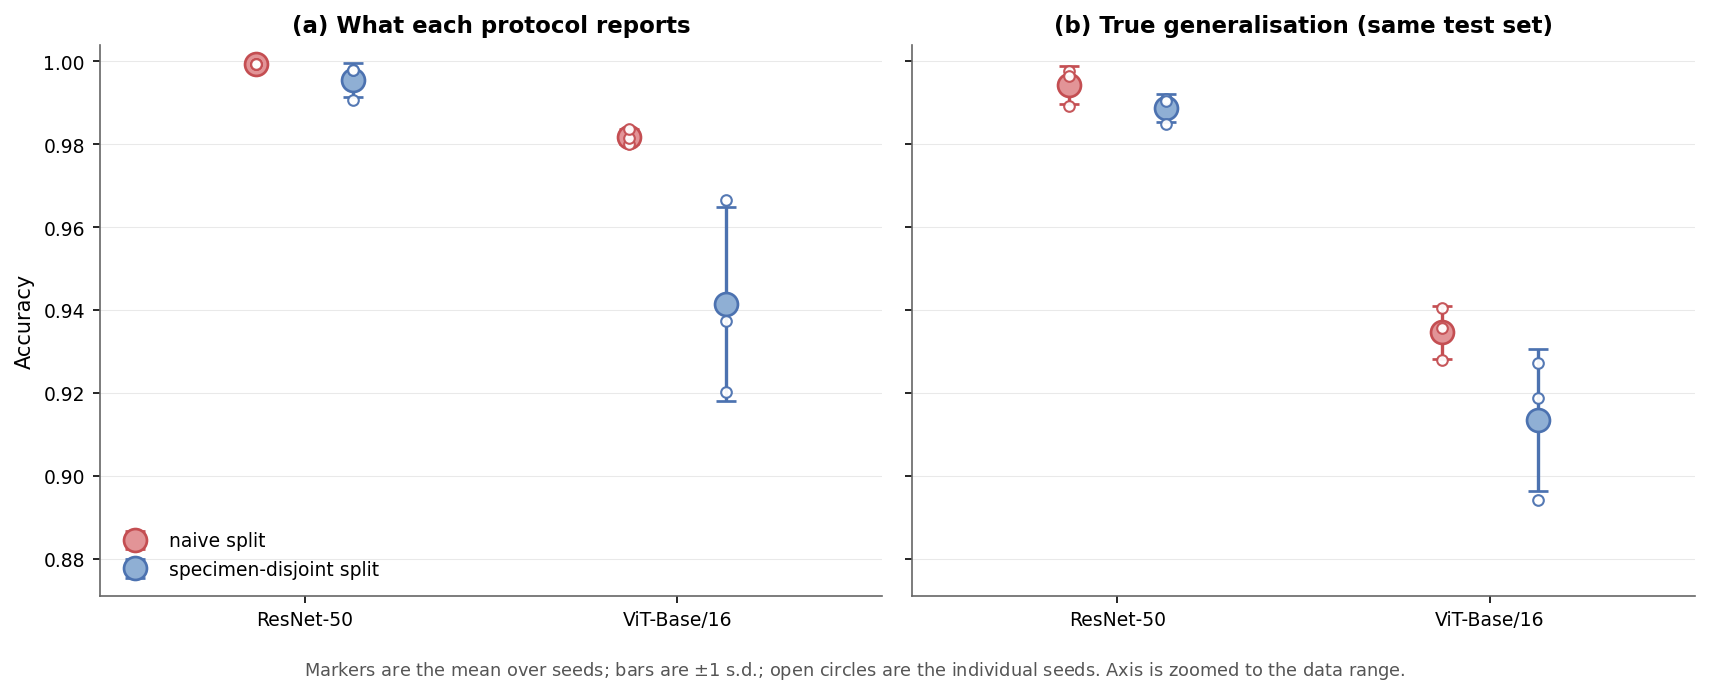


Open circles are individual seeds. Overlap between the two conditions
means the effect is not separable from seed-to-seed noise.


In [5]:
# ===== 3. Ablation figure + table (concern #3/#4) =====
# NB02 (multi-seed) writes ablation_runs.csv + ablation_effects.csv.
abl=None; abl_runs=None
_runs_p = Path(P_ABLATION)/'ablation_runs.csv'
_eff_p  = Path(P_ABLATION)/'ablation_effects.csv'
if _runs_p.exists():
    abl_runs=pd.read_csv(_runs_p)
    print(f'ablation runs: {len(abl_runs)} rows, '
          f'{abl_runs.seed.nunique()} seeds, {abl_runs.model.nunique()} models')
    if _eff_p.exists():
        abl=pd.read_csv(_eff_p); print(); print(abl.round(4).to_string(index=False))

    # Mean +/- s.d. with individual seeds shown. A bar chart anchored at 0 wastes
    # 94% of the panel and hides the effect; a truncated bar chart is misleading.
    # An interval plot has neither problem, so the axis can be zoomed honestly.
    MODELS=[m for m in PAL if m in set(abl_runs.model)]
    fig,axes=plt.subplots(1,2,figsize=(11.5,4.4),sharey=True)
    allv=[]
    for ax,(colname,title,ylab) in zip(axes,[
        ('own_test_acc','(a) What each protocol reports','Accuracy on own test set'),
        ('common_test_acc','(b) True generalisation (same test set)','Accuracy on common test')]):
        off_={'naive':-0.13,'group':+0.13}; x=np.arange(len(MODELS))
        for cond,lab in [('naive','naive split'),('group','specimen-disjoint split')]:
            mu=[]; sd=[]
            for j,arch in enumerate(MODELS):
                v=abl_runs[(abl_runs.model==arch)&(abl_runs.condition==cond)][colname].values
                allv.extend(v.tolist())
                mu.append(np.mean(v) if len(v) else np.nan)
                sd.append(np.std(v,ddof=1) if len(v)>1 else 0.0)
                ax.scatter(np.full(len(v),x[j]+off_[cond]),v,s=26,zorder=4,
                           facecolor='white',edgecolor=COND_DK[cond],lw=1.0,alpha=.95)
            ax.errorbar(x+off_[cond],mu,yerr=sd,fmt='o',ms=11,lw=0,elinewidth=1.6,
                        capsize=5,capthick=1.6,zorder=3,
                        color=COND[cond],markeredgecolor=COND_DK[cond],
                        markeredgewidth=1.3,ecolor=COND_DK[cond],label=lab)
        ax.set_xticks(x); ax.set_xticklabels([NAT.get(m,m) for m in MODELS])
        ax.set_xlim(-0.55,len(MODELS)-0.45)
        ax.set_title(title); ax.grid(axis='y',alpha=.28); ax.grid(axis='x',visible=False)
        if ax is axes[0]: ax.set_ylabel('Accuracy')
        else: ax.set_ylabel('')
    lo,hi=min(allv),max(allv); pad=max(0.012,(hi-lo)*0.22)
    axes[0].set_ylim(lo-pad, min(1.004, hi+pad))
    axes[0].legend(fontsize=9,loc='lower left',ncol=1)
    fig.text(0.5,-0.035,'Markers are the mean over seeds; bars are $\\pm$1 s.d.; '
             'open circles are the individual seeds. Axis is zoomed to the data range.',
             ha='center',fontsize=8.5,color='#555')
    plt.tight_layout(); save_fig(fig,'fig_ablation_corrected'); plt.show()
    print('\nOpen circles are individual seeds. Overlap between the two conditions')
    print('means the effect is not separable from seed-to-seed noise.')
else:
    print('No ablation_runs.csv at', P_ABLATION)
    print('Attach the MULTI-SEED NB02 output (the one with 12 rows).')


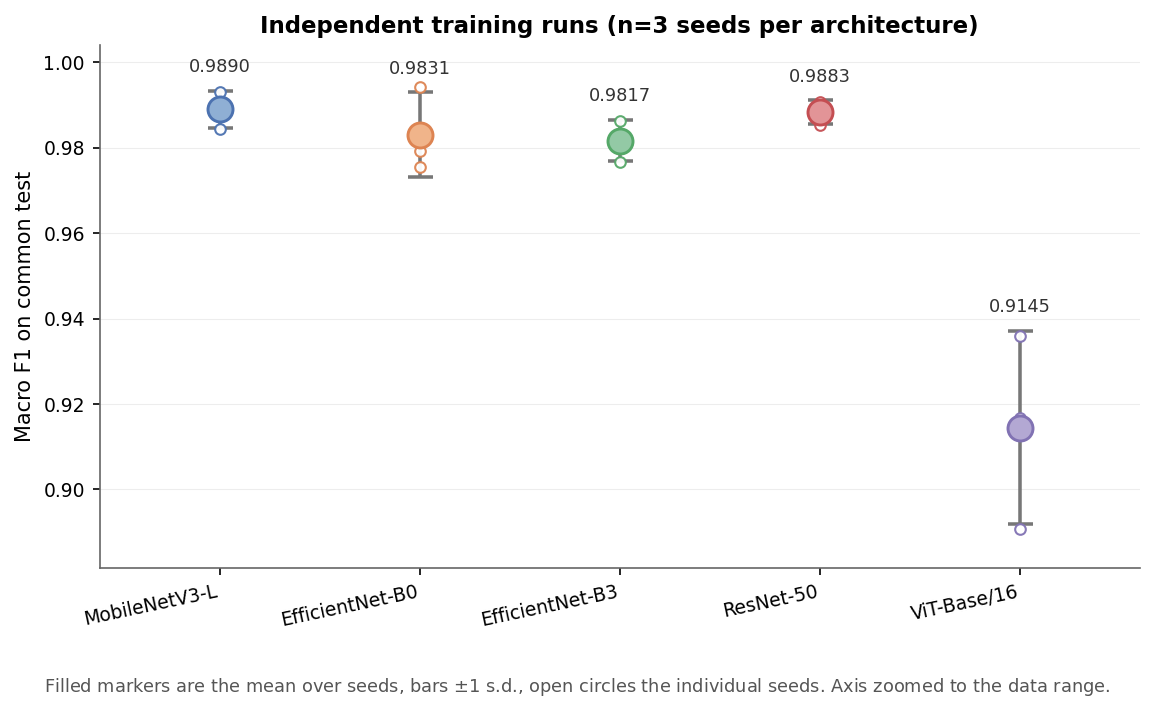

In [6]:
# ===== 4. Per-model performance figure =====
# Zoomed interval plot rather than a 0-anchored bar chart: every value lies in
# [0.91, 0.99], so bars from zero make the architectures look identical.
ms=[m for m in PAL if m in set(runs.model)]
means=np.array([runs[runs.model==m].f1_macro.mean() for m in ms])
sds=np.array([runs[runs.model==m].f1_macro.std(ddof=1) for m in ms])
sds=np.nan_to_num(sds)
fig,ax=plt.subplots(figsize=(7.8,4.4))
x=np.arange(len(ms))
for i,m in enumerate(ms):
    v=runs[runs.model==m].f1_macro.values
    ax.scatter(np.full(len(v),x[i]),v,s=26,facecolor='white',
               edgecolor=PAL_DK[m],lw=1.0,zorder=4,alpha=.95)
ax.errorbar(x,means,yerr=sds,fmt='o',ms=12,lw=0,elinewidth=1.7,capsize=6,capthick=1.7,
            zorder=3,color='none',ecolor='#777')
for i,m in enumerate(ms):
    ax.plot(x[i],means[i],'o',ms=12,color=PAL[m],markeredgecolor=PAL_DK[m],
            markeredgewidth=1.4,zorder=5)
lo=float((means-sds).min()); hi=float((means+sds).max()); span=hi-lo
ax.set_ylim(lo-max(0.004,span*0.10), min(1.004, hi+max(0.006,span*0.22)))
for i,(mu,sd) in enumerate(zip(means,sds)):
    ax.annotate(f'{mu:.4f}',(x[i],mu+sd),textcoords='offset points',xytext=(0,9),
                ha='center',fontsize=8.5,color='#333')
ax.set_xticks(x); ax.set_xticklabels([NAT[m] for m in ms],rotation=12,ha='right')
ax.set_xlim(-0.6,len(ms)-0.4)
ax.set_ylabel('Macro F1 on common test')
ax.set_title(f'Independent training runs (n={int(n_seeds.min())} seeds per architecture)')
ax.grid(axis='x',visible=False)
fig.text(0.5,-0.06,'Filled markers are the mean over seeds, bars $\\pm$1 s.d., '
         'open circles the individual seeds. Axis zoomed to the data range.',
         ha='center',fontsize=8.5,color='#555')
plt.tight_layout(); save_fig(fig,'fig_model_comparison'); plt.show()


In [7]:
# ===== 5. Assemble the numbers for the rewrite =====
sp=json.load(open(P_SPLITS/'splits.json')) if (P_SPLITS/'splits.json').exists() else {}
knn=json.load(open(P_SHORT/'knn_color_per_class.json')) if (P_SHORT/'knn_color_per_class.json').exists() else None
gray=json.load(open(P_SHORT/'grayscale_ablation.json')) if (P_SHORT/'grayscale_ablation.json').exists() else None
ext=json.load(open(P_SHORT/'external_validation.json')) if (P_SHORT/'external_validation.json').exists() else None

final={'splits':sp,'independent_runs':runs.to_dict('records'),
       'summary':json.loads(summ.reset_index().to_json(orient='records')),'statistics':stats_out,
       'ablation':abl.to_dict('records') if abl is not None else None,
       'colour_knn':knn,'grayscale_ablation':gray,'external_validation':ext}
json.dump(final,open(OUT_DIR/'REVISION_RESULTS.json','w'),indent=2,default=float)

L=[]
L.append('# Numbers for the revised manuscript\n')
L.append('Generated by NB06. Every value below comes from a re-run experiment.\n')
L.append('## Splits (concern #1, #2)\n')
if sp:
    t=sp.get('totals',{})
    L.append(f"- {t.get('images','?')} images, {t.get('classes','?')} classes, "
             f"{t.get('sessions','?')} sessions, {t.get('phash_clusters','?')} pHash clusters, "
             f"**{t.get('specimens','?')} specimens**")
    L.append(f"- Common held-out test: {sp['common_test']['images']} images / "
             f"{sp['common_test']['specimens']} specimens, specimen-disjoint")
    L.append(f"- Naive condition leaks {sp.get('naive_specimens_leaked','?')} specimens across parts (intentional)")
    L.append(f"- Single-session classes (cannot be session-separated): {sp.get('single_session_classes',[])}")
    L.append('- Terminology: call this **pHash-cluster / specimen-disjoint**, NOT "session-stratified".')
L.append('\n## Corrected ablation (concern #3, #4)\n')
if abl is not None and 'effect' in abl.columns:
    for _,r in abl.iterrows():
        L.append(f"- **{NAT.get(r['model'],r['model'])}** {r['effect']} = "
                 f"{100*r['mean']:+.2f} pp (s.d. {100*r['sd']:.2f} pp over "
                 f"{int(r['n_seeds'])} seeds; per-seed {r['per_seed']})")
    L.append('\n> Old (WITHDRAWN) claim: "-0.3 pp, leakage does not inflate". That came from one')
    L.append('> model evaluated on two test sets, where ~70% of the "clean" test images were in')
    L.append('> its own training set. Replaced by the two-independent-model design above.')
L.append('\n## Statistics (concern #6, #7)\n')
L.append(f"- {stats_out['n_blocks']} **independent training runs** per architecture, evaluated on common test")
if stats_out.get('friedman'):
    fr=stats_out['friedman']
    L.append(f"- Friedman chi2({fr['df']}) = {fr['chi2']:.4f}, p = {fr['p']:.3g}")
if stats_out.get('power_warning'): L.append(f"- {stats_out['power_warning']}")
L.append('- Do NOT describe this as cross-validation. The previous "15-fold CV" re-scored one')
L.append('  checkpoint on partitions of its own training pool and must be removed.')
L.append('\n## Colour shortcut (concern #8)\n')
if knn: L.append(f"- Colour-only kNN on clean test: acc = {knn['accuracy']:.4f} (chance ~ {1/len(knn['per_class_f1']):.3f})")
if gray and gray.get('colour'):
    L.append(f"- ResNet-50 colour-trained {gray['colour']['accuracy']:.4f} vs grayscale-trained "
             f"{gray['grayscale']['accuracy']:.4f} -> drop {gray['colour']['accuracy']-gray['grayscale']['accuracy']:+.4f}")
L.append('\n## External validation (concern #5)\n')
if ext: L.append(f"- Zero-shot external: acc = {ext['accuracy']:.4f} on {ext.get('n_images','?')} images. Put this in the ABSTRACT.")
else:   L.append('- NOT YET RUN. Attach an external dataset in NB05 - this is the strongest answer to #5.')
open(OUT_DIR/'manuscript_numbers.md','w').write('\n'.join(L))
print('\n'.join(L))
print('\n\nSaved to',OUT_DIR)

# Numbers for the revised manuscript

Generated by NB06. Every value below comes from a re-run experiment.

## Splits (concern #1, #2)

- 11094 images, 11 classes, 26 sessions, 5923 pHash clusters, **854 specimens**
- Common held-out test: 1665 images / 265 specimens, specimen-disjoint
- Naive condition leaks 520 specimens across parts (intentional)
- Single-session classes (cannot be session-separated): ['Fungal Stripe Damage', 'Leaf Blight Disease', 'White Spot', 'Yellow Mosaic Virus']
- Terminology: call this **pHash-cluster / specimen-disjoint**, NOT "session-stratified".

## Corrected ablation (concern #3, #4)

- **ResNet-50** reporting_inflation = +0.38 pp (s.d. 0.41 pp over 3 seeds; per-seed +0.0014, +0.0085, +0.0014)
- **ResNet-50** true_gap = -0.56 pp (s.d. 0.72 pp over 3 seeds; per-seed -0.0060, -0.0126, +0.0018)
- **ViT-Base/16** reporting_inflation = +4.04 pp (s.d. 2.44 pp over 3 seeds; per-seed +0.0463, +0.0136, +0.0612)
- **ViT-Base/16** true_gap = -2.12 pp (s.d. 2.04 pp 

prediction files found: 15


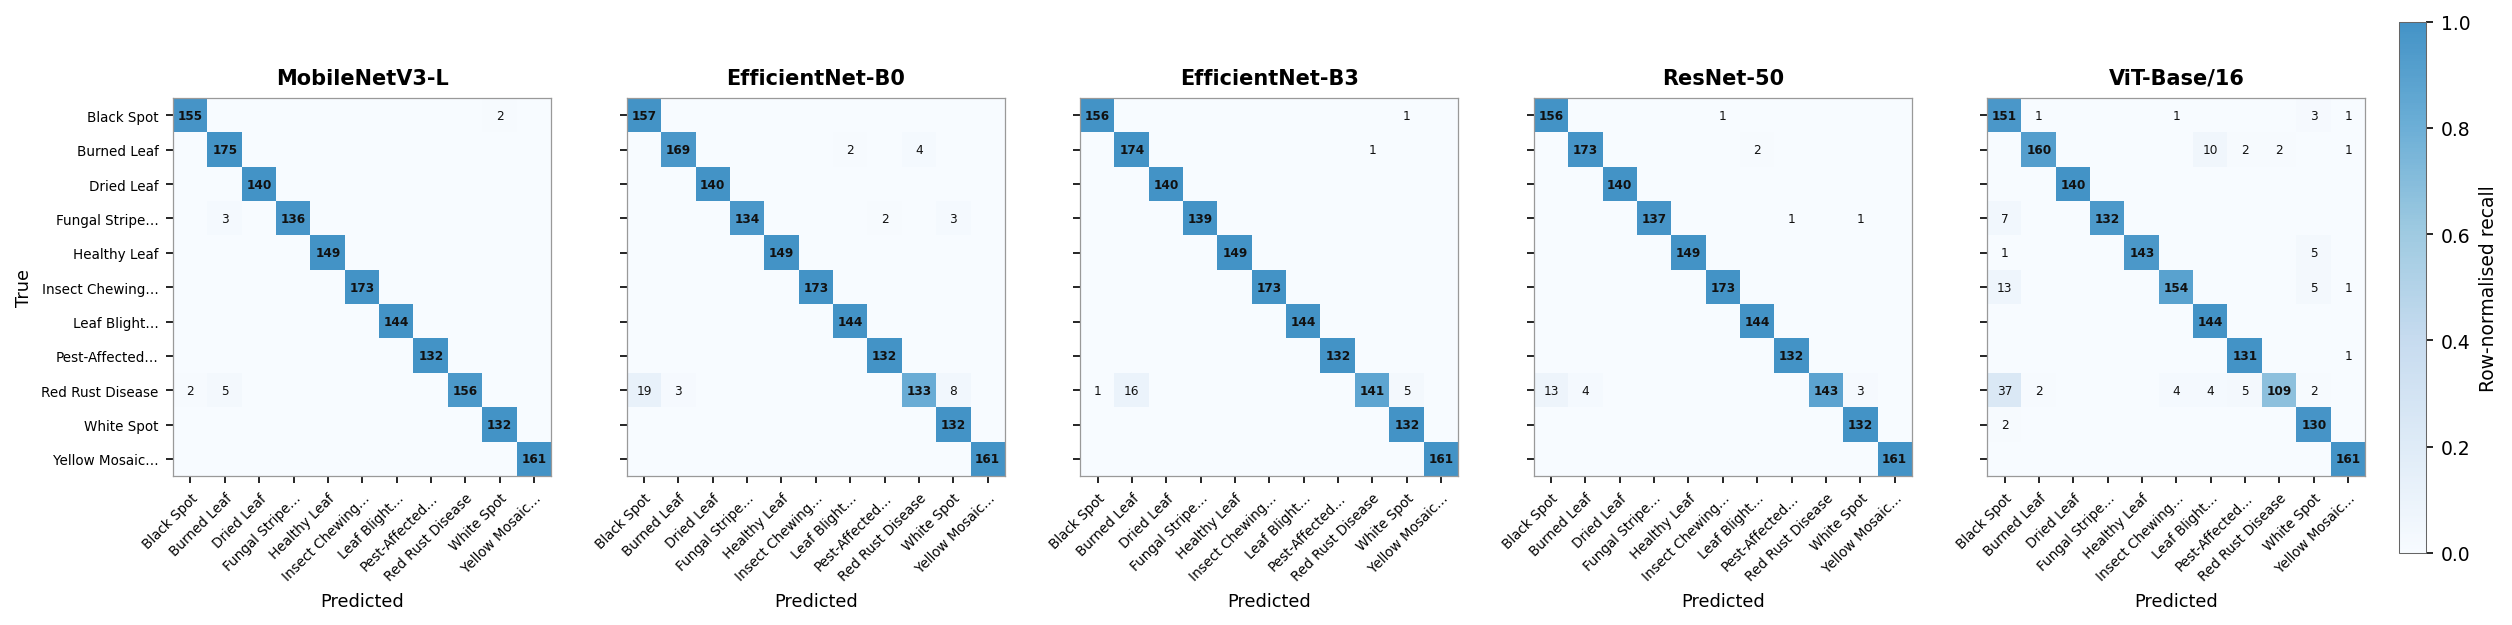

In [8]:
# ===== 7. Confusion matrices from SAVED predictions (no re-inference) =====
from sklearn.metrics import confusion_matrix, roc_curve, auc
CLASSES=json.load(open(P_CNN/'classes.json'))['classes'] if (P_CNN/'classes.json').exists() else None
NC=len(CLASSES) if CLASSES else None

def load_pred(root, tag):
    f=Path(root)/'predictions'/f'{tag}.npz'
    if not f.exists(): return None
    d=np.load(f); return d['y_true'],d['y_pred'],d['y_prob']

avail=[]
for root in [P_CNN,P_VIT]+EXTRA_RUN_DIRS:
    for f in sorted((Path(root)/'predictions').glob('*.npz')) if (Path(root)/'predictions').exists() else []:
        avail.append((root,f.stem))
print('prediction files found:',len(avail))

def short_label(c, n=16):
    """Shorten long class names so 90-degree rotation is not needed.
    Truncate on a word boundary so labels never end in a dangling ' .'."""
    if len(c)<=n: return c
    cut=c[:n].rstrip()
    if ' ' in cut: cut=cut[:cut.rfind(' ')].rstrip()
    return cut+'\u2026'

# one confusion matrix per architecture (seed 42 run)
mods=[m for m in PAL if any(t.startswith(m+'_seed42') for _,t in avail)]
if mods:
    n=len(mods)
    fig,axes=plt.subplots(1,n,figsize=(3.9*n,4.6),squeeze=False)
    for k,(ax,m) in enumerate(zip(axes[0],mods)):
        root=[r for r,t in avail if t==f'{m}_seed42'][0]
        y,p,_=load_pred(root,f'{m}_seed42')
        cm=confusion_matrix(y,p,labels=range(NC)); cmn=cm/cm.sum(1,keepdims=True).clip(min=1)
        im=ax.imshow(cmn,cmap=CMAP_CM,vmin=0,vmax=1)
        ax.set_title(NAT[m],fontsize=10,pad=7)
        ax.set_xticks(range(NC)); ax.set_yticks(range(NC))
        ax.set_xticklabels([short_label(c) for c in CLASSES],rotation=45,ha='right',
                           rotation_mode='anchor',fontsize=6.5)
        ax.set_yticklabels([short_label(c) for c in CLASSES] if k==0 else ['']*NC,fontsize=6.5)
        ax.set_xlabel('Predicted',fontsize=8.5)
        if k==0: ax.set_ylabel('True',fontsize=8.5)
        ax.grid(False)
        for i in range(NC):
            for j in range(NC):
                if cm[i,j]:
                    # colormap is truncated light, so black text is readable everywhere
                    ax.text(j,i,cm[i,j],ha='center',va='center',fontsize=5.8,
                            color='#111',fontweight='bold' if i==j else 'normal')
        for s in ax.spines.values(): s.set_visible(True); s.set_color('#999'); s.set_linewidth(.6)
    cb=fig.colorbar(im,ax=axes[0],fraction=.018,pad=.015)
    cb.set_label('Row-normalised recall',fontsize=9); cb.outline.set_linewidth(.5)
    save_fig(fig,'fig_confusion_matrices'); plt.show()


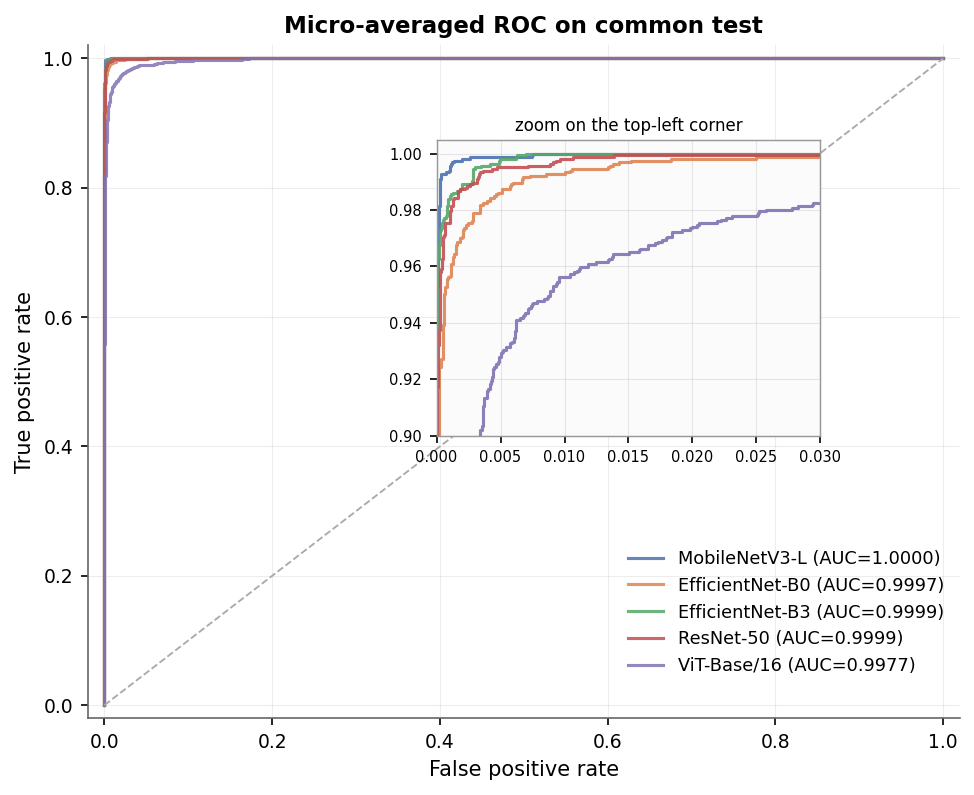

In [9]:
# ===== 8. ROC curves (macro, per architecture) =====
# All AUCs exceed 0.997, so on a full 0-1 axis every curve collapses into the
# top-left corner. The inset magnifies the only region where they differ.
if mods:
    fig,ax=plt.subplots(figsize=(6.6,5.4))
    curves={}
    for m in mods:
        root=[r for r,t in avail if t==f'{m}_seed42'][0]
        y,p,pr=load_pred(root,f'{m}_seed42')
        Y=np.eye(NC)[y]
        fpr,tpr,_=roc_curve(Y.ravel(),pr.ravel())
        curves[m]=(fpr,tpr,auc(fpr,tpr))
        ax.plot(fpr,tpr,label=f'{NAT[m]} (AUC={curves[m][2]:.4f})',
                color=PAL_DK[m],lw=1.5,alpha=.85)
    ax.plot([0,1],[0,1],'--',color='#aaa',lw=.9)
    ax.set_xlabel('False positive rate'); ax.set_ylabel('True positive rate')
    ax.set_title('Micro-averaged ROC on common test')
    ax.set_xlim(-0.02,1.02); ax.set_ylim(-0.02,1.02)
    ax.legend(fontsize=8.5,loc='lower right',bbox_to_anchor=(1.0,0.04))

    axi=ax.inset_axes([0.40,0.42,0.44,0.44])
    for m in mods:
        fpr,tpr,_=curves[m]
        axi.plot(fpr,tpr,color=PAL_DK[m],lw=1.5,alpha=.9)
    axi.set_xlim(0,0.03); axi.set_ylim(0.90,1.005)
    axi.set_title('zoom on the top-left corner',fontsize=8,fontweight='normal',pad=4)
    axi.tick_params(labelsize=7); axi.grid(alpha=.3)
    for s in axi.spines.values(): s.set_visible(True); s.set_color('#999'); s.set_linewidth(.7)
    axi.set_facecolor('#fbfbfb')
    plt.tight_layout(); save_fig(fig,'fig_roc_curves'); plt.show()


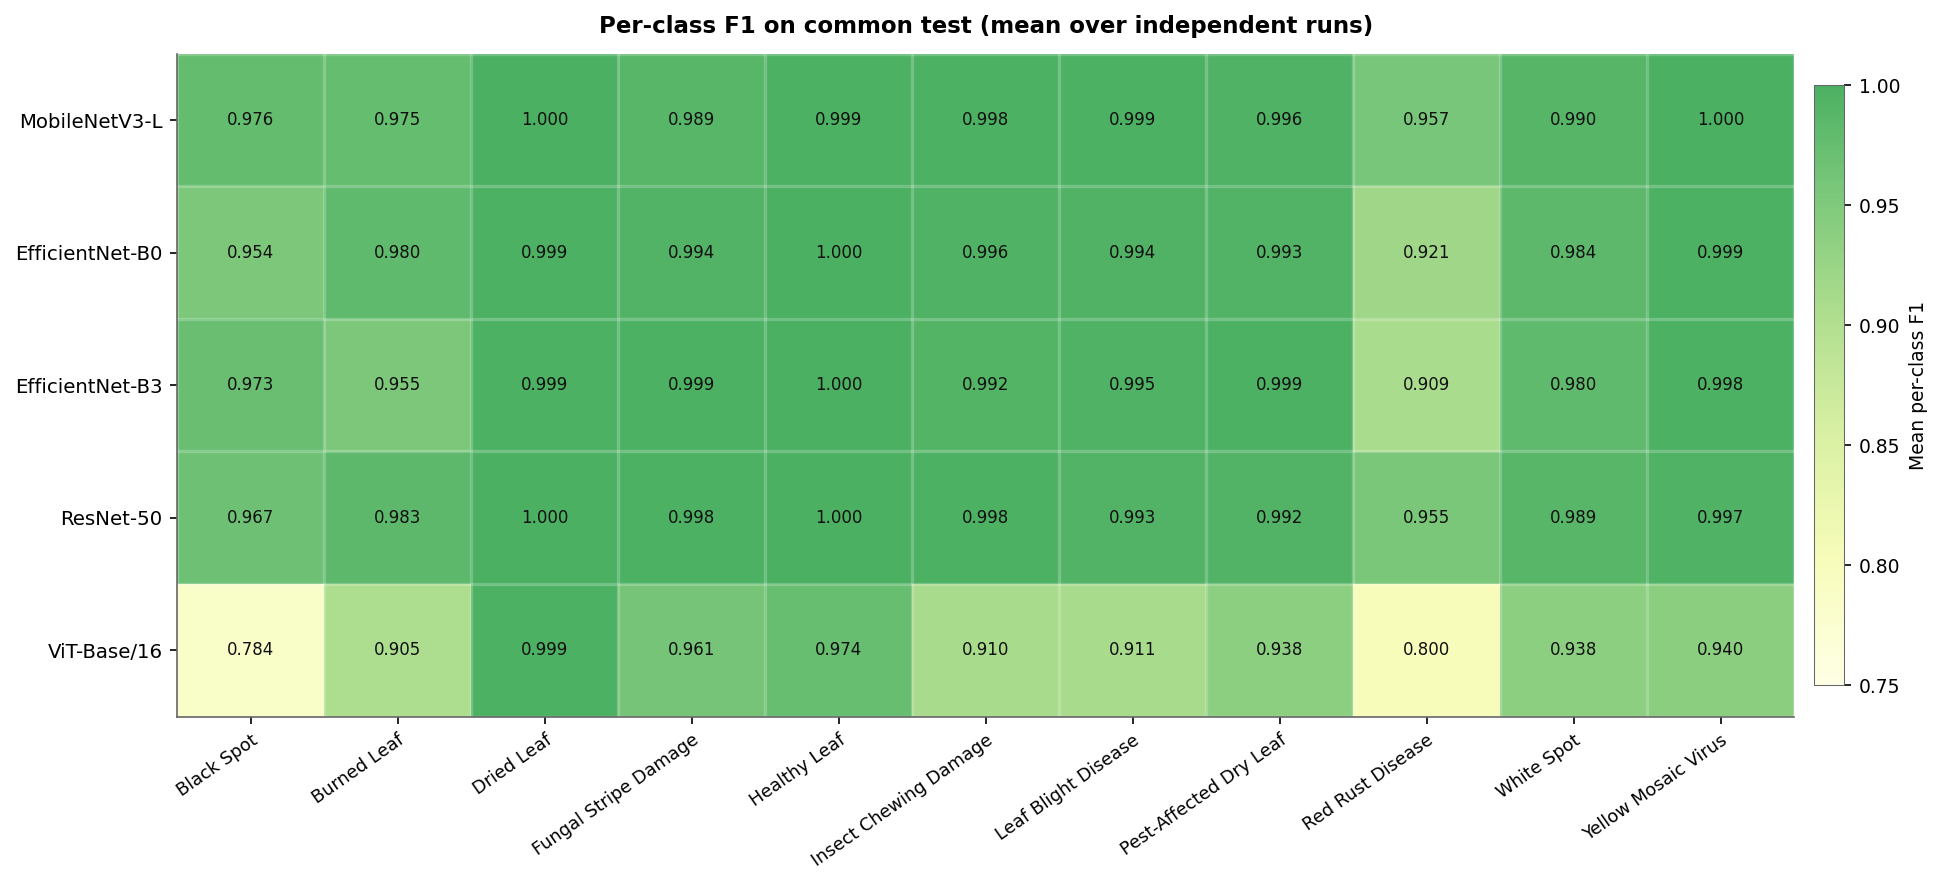

In [10]:
# ===== 9. Per-class F1 heatmap (mean over seeds) =====
pcf={}
for root in [P_CNN,P_VIT]+EXTRA_RUN_DIRS:
    f=Path(root)/'per_class_f1_runs.json'
    if f.exists(): pcf.update(json.load(open(f)))
if pcf and CLASSES:
    md_={}
    for tag,v in pcf.items():
        m=tag.rsplit('_seed',1)[0]; md_.setdefault(m,[]).append(v)
    ms=[m for m in PAL if m in md_]
    M=np.array([np.mean(md_[m],axis=0) for m in ms])
    # Light sequential map (not RdYlGn): diverging red-green is not colour-blind
    # safe and its saturated ends make the annotation text unreadable.
    fig,ax=plt.subplots(figsize=(0.95*len(CLASSES)+2.6,0.62*len(ms)+2.9))
    vmin=max(0.0,np.floor(M.min()*20)/20)
    im=ax.imshow(M,cmap=CMAP_F1,vmin=vmin,vmax=1.0,aspect='auto')
    ax.set_xticks(range(len(CLASSES)))
    ax.set_xticklabels(CLASSES,rotation=35,ha='right',rotation_mode='anchor',fontsize=8.5)
    ax.set_yticks(range(len(ms))); ax.set_yticklabels([NAT[m] for m in ms],fontsize=9.5)
    ax.set_xticks(np.arange(-.5,len(CLASSES),1),minor=True)
    ax.set_yticks(np.arange(-.5,len(ms),1),minor=True)
    ax.grid(which='minor',color='white',linewidth=1.6); ax.grid(which='major',visible=False)
    ax.tick_params(which='minor',length=0)
    for i in range(len(ms)):
        for j in range(len(CLASSES)):
            ax.text(j,i,f'{M[i,j]:.3f}',ha='center',va='center',fontsize=8,color='#111')
    cb=fig.colorbar(im,ax=ax,fraction=.018,pad=.012)
    cb.set_label('Mean per-class F1',fontsize=9); cb.outline.set_linewidth(.5)
    ax.set_title('Per-class F1 on common test (mean over independent runs)',pad=10)
    plt.tight_layout(); save_fig(fig,'fig_per_class_f1'); plt.show()


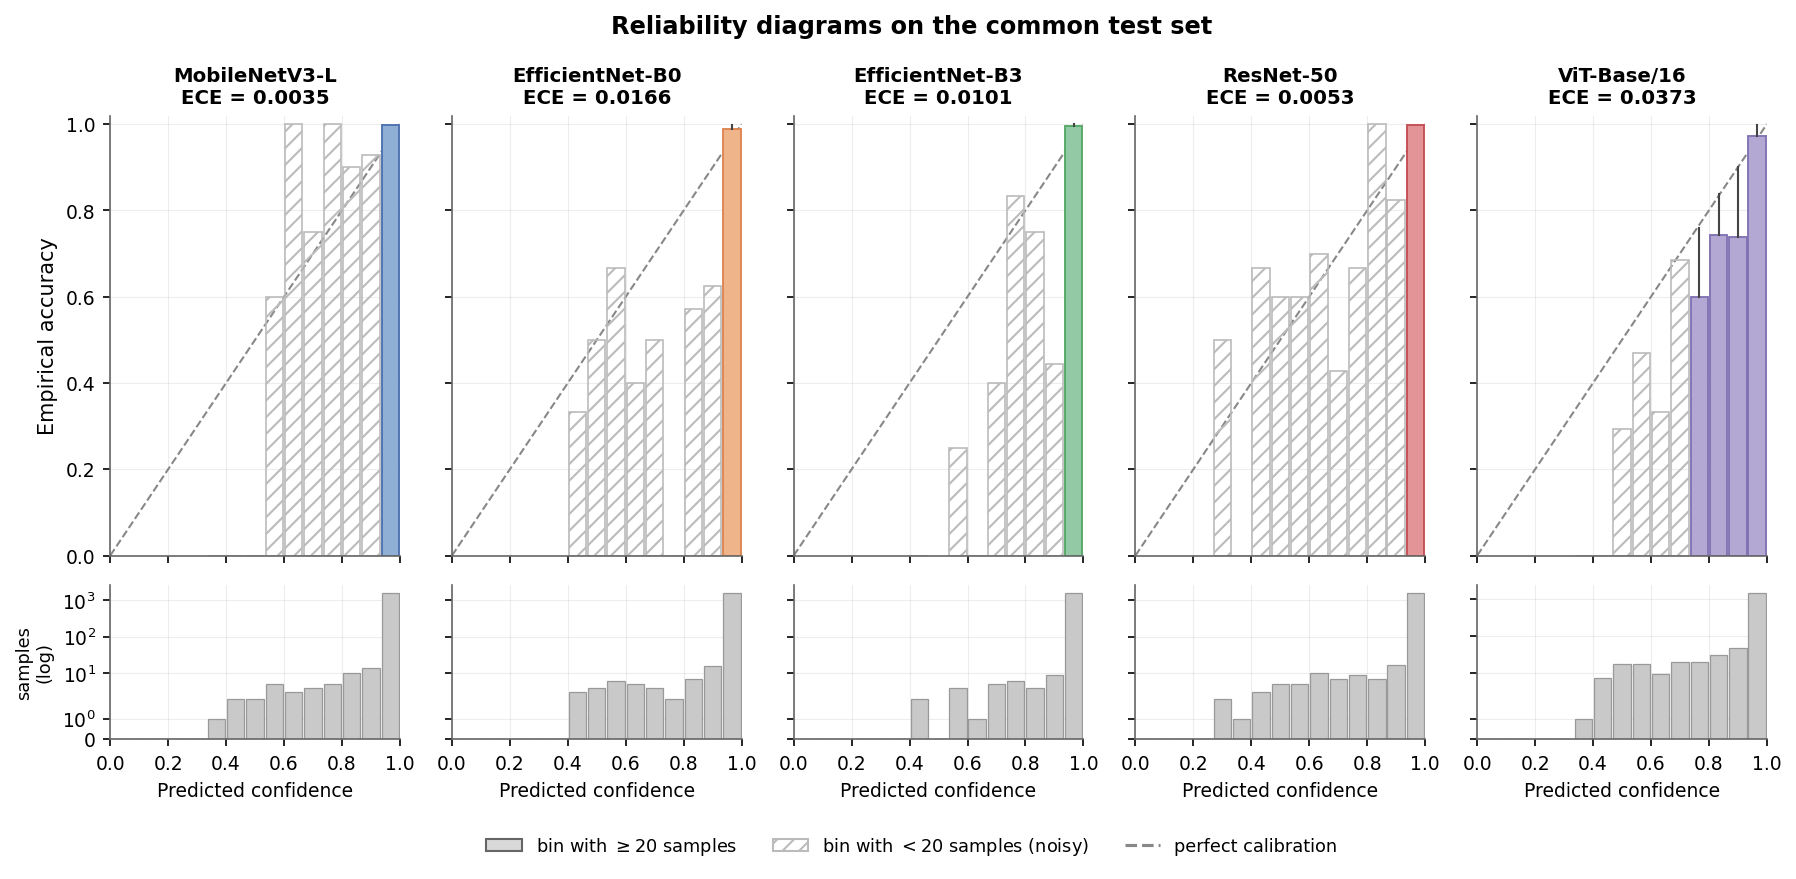

          model    ECE
  MobileNetV3-L 0.0035
      ResNet-50 0.0053
EfficientNet-B3 0.0101
EfficientNet-B0 0.0166
    ViT-Base/16 0.0373

Concentration check (MobileNetV3-L): 1619/1665 = 97.2% of predictions fall in the top confidence bin, which is why the low-confidence bins are noisy.


In [11]:
# ===== 10. Calibration / reliability diagram =====
# The previous version drew all five models as connected lines over every non-empty
# bin. Because >90% of predictions land in the top confidence bin, the low-confidence
# bins hold 1-5 samples each, so their empirical accuracy can only take values like
# 0, 1/3, 1/2 or 1. Joining those points produced a zig-zag that is pure sampling
# noise, not miscalibration, and five overlapping zig-zags were unreadable.
#
# Rebuilt as the standard Guo et al. reliability diagram: one panel per model,
# bin accuracy drawn as bars against the diagonal, with the bin-count histogram
# underneath so the reader can see which bins carry any weight. Bins holding fewer
# than MIN_BIN_N samples are drawn hatched to mark them as unreliable.
MIN_BIN_N = 20

cal={}
for root in [P_CNN,P_VIT]+EXTRA_RUN_DIRS:
    d=Path(root)/'calibration'
    if d.exists():
        for f in d.glob('*seed42.json'): cal[f.stem]=json.load(open(f))

if cal:
    order=[m for m in PAL if any(t.rsplit('_seed',1)[0]==m for t in cal)]
    tags=[next(t for t in cal if t.rsplit('_seed',1)[0]==m) for m in order]
    n=len(order)
    fig,axes=plt.subplots(2,n,figsize=(2.85*n,5.4),sharex=True,
                          gridspec_kw={'height_ratios':[3,1.05],'hspace':0.10,'wspace':0.18})
    if n==1: axes=axes.reshape(2,1)
    rows=[]
    for k,(m,tag) in enumerate(zip(order,tags)):
        c=cal[tag]; ax=axes[0,k]; axh=axes[1,k]
        b=np.array([r for r in c['bins']],dtype=float)
        lo,hi,cnt,acc,conf=b[:,0],b[:,1],b[:,2],b[:,3],b[:,4]
        mid=(lo+hi)/2; w=(hi-lo)*0.9
        ok=(cnt>=MIN_BIN_N); sparse=(cnt>0)&(~ok)

        ax.plot([0,1],[0,1],'--',color='#888',lw=1.0,zorder=1)
        ax.bar(mid[ok],np.nan_to_num(acc[ok]),width=w[ok],color=PAL.get(m,'#ccc'),
               edgecolor=PAL_DK.get(m,'#666'),lw=.9,zorder=2)
        ax.bar(mid[sparse],np.nan_to_num(acc[sparse]),width=w[sparse],color='none',
               edgecolor='#bbb',lw=.8,hatch='///',zorder=2)
        # gap between confidence and accuracy, on the reliable bins only
        for j in np.flatnonzero(ok):
            ax.plot([mid[j],mid[j]],[acc[j],conf[j]],color='#444',lw=1.0,zorder=3)
        ax.set_xlim(0,1); ax.set_ylim(0,1.02)
        ax.set_title(f'{NAT.get(m,m)}\nECE = {c["ece"]:.4f}',fontsize=9.5,pad=6)
        ax.grid(alpha=.22)
        if k==0: ax.set_ylabel('Empirical accuracy')
        else: ax.set_yticklabels([])

        axh.bar(mid,np.maximum(cnt,0),width=w,color='#c9c9c9',edgecolor='#999',lw=.6)
        axh.set_yscale('symlog'); axh.set_xlim(0,1)
        axh.set_xlabel('Predicted confidence',fontsize=9)
        axh.grid(alpha=.22)
        if k==0: axh.set_ylabel('samples\n(log)',fontsize=8.5)
        else: axh.set_yticklabels([])
        rows.append({'model':NAT.get(m,m),'ECE':c['ece']})

    from matplotlib.patches import Patch
    fig.legend(handles=[
        Patch(facecolor='#d9d9d9',edgecolor='#666',label=f'bin with $\\geq${MIN_BIN_N} samples'),
        Patch(facecolor='none',edgecolor='#bbb',hatch='///',label=f'bin with $<${MIN_BIN_N} samples (noisy)'),
        plt.Line2D([0],[0],ls='--',color='#888',label='perfect calibration')],
        loc='lower center',ncol=3,fontsize=8.5,bbox_to_anchor=(0.5,-0.055))
    fig.suptitle('Reliability diagrams on the common test set',
                 fontsize=11.5,fontweight='bold',y=1.005)
    save_fig(fig,'fig_calibration'); plt.show()

    cal_df=pd.DataFrame(rows).sort_values('ECE'); print(cal_df.round(4).to_string(index=False))
    cal_df.to_csv(OUT_DIR/'calibration_summary.csv',index=False)
    _tot=int(sum(r[2] for r in cal[tags[0]]['bins']))
    _top=int(cal[tags[0]]['bins'][-1][2])
    print(f'\nConcentration check ({NAT.get(order[0],order[0])}): '
          f'{_top}/{_tot} = {_top/max(_tot,1):.1%} of predictions fall in the top '
          f'confidence bin, which is why the low-confidence bins are noisy.')
else:
    cal_df=None; print('no calibration files found')


histories found: 39


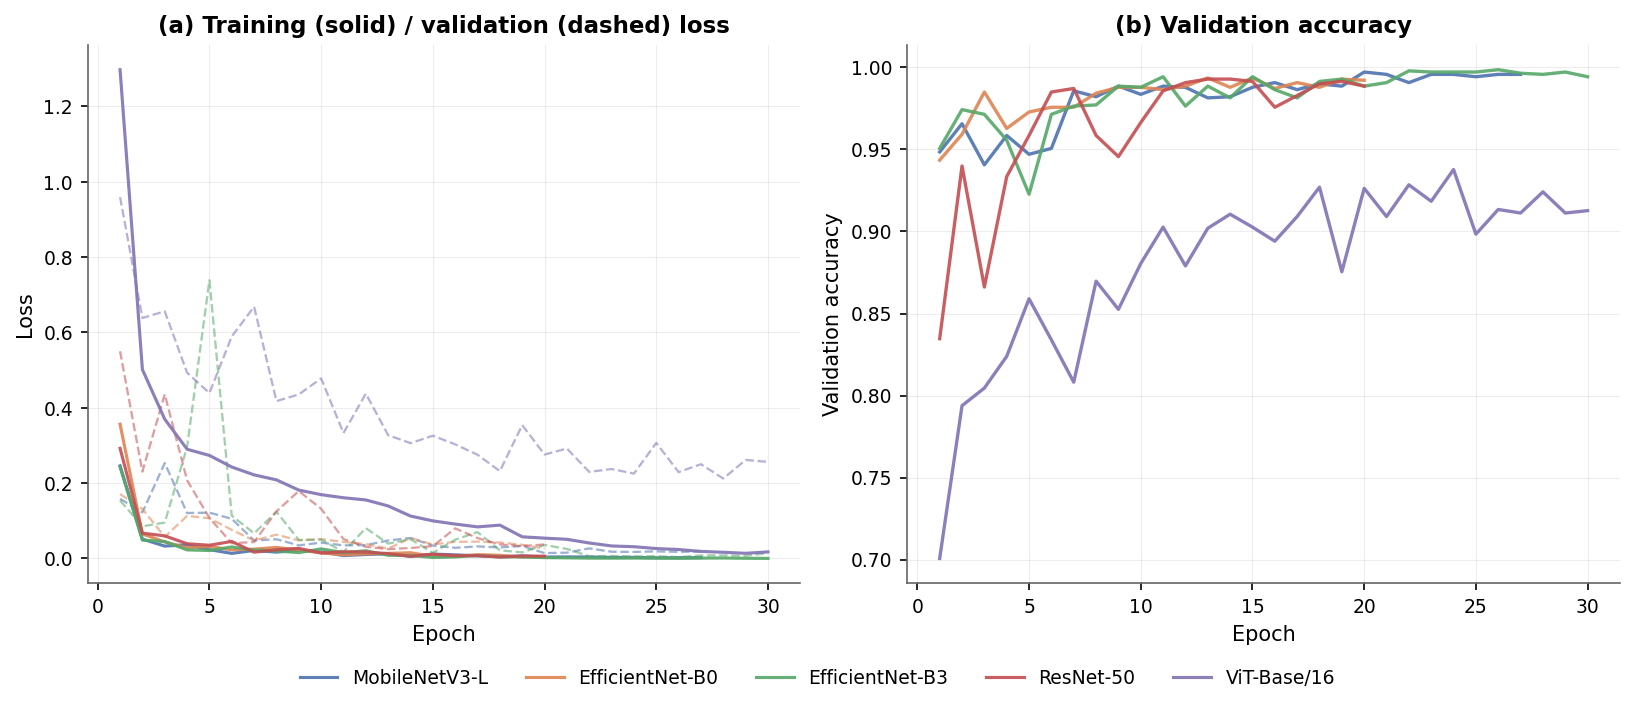

In [12]:
# ===== 11. Training convergence curves (real histories) =====
hists={}
for root in [P_CNN,P_VIT,P_ABLATION]+EXTRA_RUN_DIRS:
    d=Path(root)/'histories'
    if d.exists():
        for f in d.glob('*.json'): hists[f.stem]=json.load(open(f))
print('histories found:',len(hists))
sel={k:v for k,v in hists.items() if k.endswith('seed42')}
if sel:
    order=[m for m in PAL if any(t.rsplit('_seed',1)[0]==m for t in sel)]
    fig,ax=plt.subplots(1,2,figsize=(11,4.5))
    handles=[]
    for m in order:
        tag=next(t for t in sel if t.rsplit('_seed',1)[0]==m); h=sel[tag]
        c=PAL_DK.get(m,'gray')
        l,=ax[0].plot(range(1,len(h['train_loss'])+1),h['train_loss'],color=c,lw=1.5,alpha=.9)
        ax[0].plot(range(1,len(h['val_loss'])+1),h['val_loss'],color=c,lw=1.1,ls='--',alpha=.55)
        ax[1].plot(range(1,len(h['val_acc'])+1),h['val_acc'],color=c,lw=1.6,alpha=.9)
        handles.append((l,NAT.get(m,m)))
    ax[0].set_xlabel('Epoch'); ax[0].set_ylabel('Loss')
    ax[0].set_title('(a) Training (solid) / validation (dashed) loss')
    ax[1].set_xlabel('Epoch'); ax[1].set_ylabel('Validation accuracy')
    ax[1].set_title('(b) Validation accuracy')
    # one shared legend below both panels instead of a legend inside each
    fig.legend([h for h,_ in handles],[n for _,n in handles],
               loc='lower center',ncol=len(handles),fontsize=9,
               bbox_to_anchor=(0.5,-0.055))
    plt.tight_layout(); save_fig(fig,'fig_convergence'); plt.show()


In [13]:
# ===== 12. LaTeX tables for the manuscript =====
TEXD=OUT_DIR/'tables'; TEXD.mkdir(exist_ok=True)
def _manual_latex(df_, caption, label, col=None, fmt=None):
    """Fallback: pandas.to_latex can require a newer jinja2 than the runtime has."""
    fmt = fmt or (lambda v: f'{v:.4f}')
    def cellfmt(v):
        if isinstance(v,float): return fmt(v)
        return str(v).replace('_','\\_').replace('%','\\%').replace('&','\\&')
    ncol=len(df_.columns); col=col or ('l'+'r'*(ncol-1))
    L=['\\begin{table}[t]','\\centering',f'\\caption{{{caption}}}',f'\\label{{{label}}}',
       f'\\begin{{tabular}}{{{col}}}','\\toprule',
       ' & '.join(str(c).replace('_','\\_') for c in df_.columns)+' \\\\','\\midrule']
    for _,r in df_.iterrows():
        L.append(' & '.join(cellfmt(v) for v in r.values)+' \\\\')
    L += ['\\bottomrule','\\end{tabular}','\\end{table}']
    return '\n'.join(L)

def emit(df_,name,caption,label,fmt=None,col=None):
    try:
        tex=df_.to_latex(index=False,escape=True,
                         float_format=fmt or (lambda v:f'{v:.4f}'),
                         column_format=col,caption=caption,label=label)
    except Exception as e:
        print(f'  [to_latex unavailable ({type(e).__name__}); using manual writer]')
        tex=_manual_latex(df_,caption,label,col,fmt)
    open(TEXD/f'{name}.tex','w').write(tex); print(f'--- {name}.tex ---'); print(tex)

# T1 main results
t1=runs.groupby('model',observed=True).agg(
    n_runs=('seed','size'),
    acc_mean=('accuracy','mean'),acc_std=('accuracy','std'),
    f1_mean=('f1_macro','mean'),f1_std=('f1_macro','std'),
    mcc_mean=('mcc','mean'),mcc_std=('mcc','std')).reset_index()
t1['Model']=[NAT.get(m,m) for m in t1.model]
t1['Accuracy']=t1.apply(lambda r:f'{r.acc_mean:.4f} ± {0 if pd.isna(r.acc_std) else r.acc_std:.4f}',axis=1)
t1['Macro F1']=t1.apply(lambda r:f'{r.f1_mean:.4f} ± {0 if pd.isna(r.f1_std) else r.f1_std:.4f}',axis=1)
t1['MCC']     =t1.apply(lambda r:f'{r.mcc_mean:.4f} ± {0 if pd.isna(r.mcc_std) else r.mcc_std:.4f}',axis=1)
emit(t1[['Model','n_runs','Accuracy','Macro F1','MCC']],'table_main_results',
 'Performance on the specimen-disjoint common test set. Mean $\pm$ s.d. over independent '
 'training runs (fresh initialisation and training per run), not cross-validation folds.',
 'tab:main_results',col='lrccc')

# T2 ablation  (schema of ablation_effects.csv from the multi-seed NB02)
if abl is not None and 'effect' in abl.columns:
    t2=abl.copy()
    t2['Model']=[NAT.get(m,m) for m in t2.model]
    t2['Effect']=t2.effect.replace({'reporting_inflation':'Reporting inflation',
                                    'true_gap':'True gap (common test)'})
    t2['Mean (pp)']=(100*t2['mean']).round(2)
    t2['s.d. (pp)']=(100*t2['sd']).round(2)
    t2['Per seed']=t2.per_seed
    t2['|mean|/s.d.']=t2.ratio_mean_over_sd.round(2)
    t2['p']=t2.p_ttest.round(3)
    emit(t2[['Model','Effect','Mean (pp)','s.d. (pp)','Per seed','|mean|/s.d.','p']],
      'table_ablation',
      'Leakage ablation over independently seeded pairs of models. Each seed contributes '
      'one (naive, specimen-disjoint) pair trained with an identical budget. Reporting '
      'inflation is the difference each protocol would publish on its own test partition; '
      'the true gap compares both models on the identical common test set. With three '
      'seeds these effects are indicative rather than conclusive; the pooled relationship '
      'in Table~\\ref{tab:headroom} is the stronger statement.',
      'tab:ablation',col='llrrlrr')
elif abl is not None:
    print('ablation_effects.csv has an unexpected schema; skipping T2')

# T3 statistics
if stats_out.get('friedman'):
    pw=stats_out.get('pairwise_wilcoxon',{})
    t3=pd.DataFrame([{'Comparison':k.replace('_vs_',' vs '),
                      'p (raw)':v.get('p_raw'),'p (Bonferroni)':v.get('p_corrected'),
                      'Note':v.get('note','')} for k,v in pw.items()])
    emit(t3,'table_statistics',
      f"Pairwise Wilcoxon signed-rank tests over {stats_out['n_blocks']} independent training "
      f"runs (Friedman $\chi^2({stats_out['friedman']['df']})="
      f"{stats_out['friedman']['chi2']:.2f}$, $p={stats_out['friedman']['p']:.3g}$). "
      "With few runs these tests have low power; non-significance is not evidence of equivalence.",
      'tab:statistics',col='lrrl')

# T4 shortcut / external
rows=[]
if knn: rows.append({'Experiment':'Colour-histogram kNN (no CNN)','Accuracy':knn['accuracy']})
if gray:
    if gray.get('colour'): rows.append({'Experiment':'ResNet-50, colour images','Accuracy':gray['colour']['accuracy']})
    rows.append({'Experiment':'ResNet-50, grayscale images','Accuracy':gray['grayscale']['accuracy']})
if ext: rows.append({'Experiment':'ResNet-50, zero-shot external dataset','Accuracy':ext['accuracy']})
if rows:
    emit(pd.DataFrame(rows),'table_shortcut_external',
     'Shortcut-learning probes and external validation. A high colour-only baseline and a '
     'small colour-to-grayscale drop both indicate reliance on colour rather than lesion '
     'morphology; the external row measures transfer beyond the collection conditions.',
     'tab:shortcut',col='lr')
if cal_df is not None:
    emit(cal_df,'table_calibration','Expected calibration error (15 bins) on the common test set.',
         'tab:calibration',col='lr')
print('\nTables written to',TEXD)

--- table_main_results.tex ---
\begin{table}
\caption{Performance on the specimen-disjoint common test set. Mean $\pm$ s.d. over independent training runs (fresh initialisation and training per run), not cross-validation folds.}
\label{tab:main_results}
\begin{tabular}{lrccc}
\toprule
Model & n\_runs & Accuracy & Macro F1 & MCC \\
\midrule
MobileNetV3-L & 3 & 0.9886 ± 0.0045 & 0.9890 ± 0.0044 & 0.9875 ± 0.0050 \\
EfficientNet-B0 & 3 & 0.9826 ± 0.0100 & 0.9831 ± 0.0099 & 0.9810 ± 0.0109 \\
EfficientNet-B3 & 3 & 0.9808 ± 0.0051 & 0.9817 ± 0.0048 & 0.9790 ± 0.0057 \\
ResNet-50 & 3 & 0.9880 ± 0.0028 & 0.9883 ± 0.0028 & 0.9868 ± 0.0030 \\
ViT-Base/16 & 3 & 0.9117 ± 0.0232 & 0.9145 ± 0.0226 & 0.9041 ± 0.0255 \\
\bottomrule
\end{tabular}
\end{table}

--- table_ablation.tex ---
\begin{table}
\caption{Leakage ablation over independently seeded pairs of models. Each seed contributes one (naive, specimen-disjoint) pair trained with an identical budget. Reporting inflation is the difference each p

<>:39: SyntaxWarning: invalid escape sequence '\p'
<>:74: SyntaxWarning: invalid escape sequence '\c'
<>:39: SyntaxWarning: invalid escape sequence '\p'
<>:74: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_23/1889698126.py:39: SyntaxWarning: invalid escape sequence '\p'
  'Performance on the specimen-disjoint common test set. Mean $\pm$ s.d. over independent '
/tmp/ipykernel_23/1889698126.py:74: SyntaxWarning: invalid escape sequence '\c'
  f"runs (Friedman $\chi^2({stats_out['friedman']['df']})="


  EfficientNet-B0    acc 0.9759 [0.9605, 0.9888]   F1 0.9752 [0.9609, 0.9878]   (265 specimens)
  EfficientNet-B3    acc 0.9866 [0.9703, 0.9973]   F1 0.9867 [0.9726, 0.9973]   (265 specimens)
  MobileNetV3-L      acc 0.9933 [0.9857, 0.9987]   F1 0.9934 [0.9866, 0.9986]   (265 specimens)
  ResNet-50          acc 0.9852 [0.9738, 0.9943]   F1 0.9852 [0.9747, 0.9938]   (265 specimens)
  ViT-Base/16        acc 0.9350 [0.9054, 0.9597]   F1 0.9350 [0.9076, 0.9584]   (265 specimens)
--- table_specimen_bootstrap.tex ---
\begin{table}
\caption{Performance on the common test set with 95\% confidence intervals from a specimen-level (cluster) bootstrap, 1000 resamples. Specimens, not images, are resampled: images of the same leaf are correlated, so an image-level bootstrap would understate the interval.}
\label{tab:specimen_bootstrap}
\begin{tabular}{lrll}
\toprule
Model & Test specimens & Accuracy (95\% CI) & Macro F1 (95\% CI) \\
\midrule
EfficientNet-B0 & 265 & 0.9759 [0.9605, 0.9888] & 0.9752 [

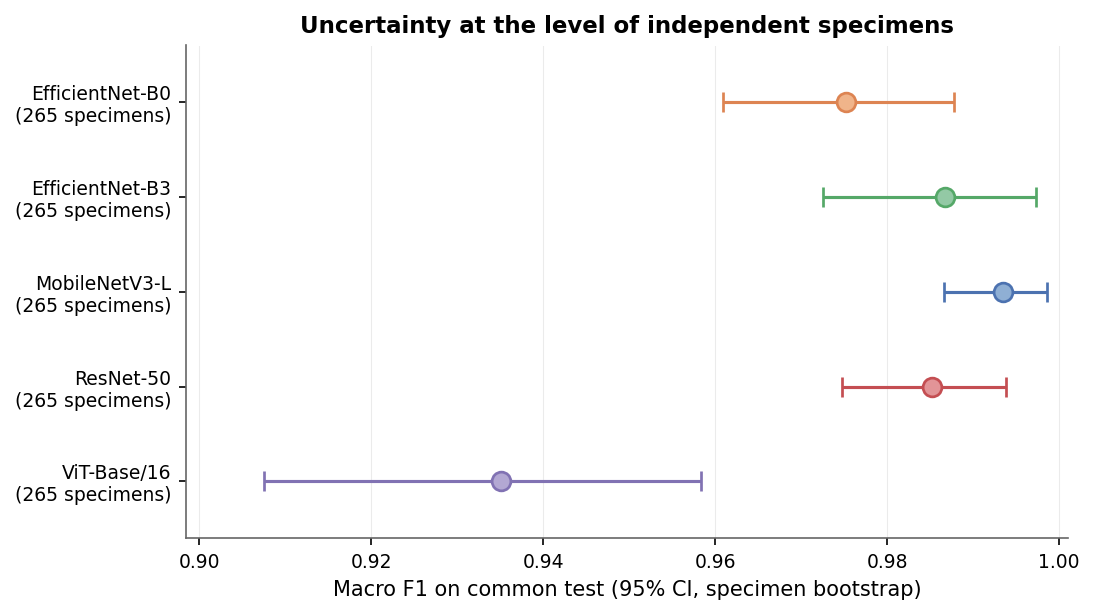

In [14]:
# ===== 13. SPECIMEN-LEVEL BOOTSTRAP  (the statistically correct interval) =====
# Images inside one specimen are the same leaf and are strongly correlated. Bootstrapping
# over IMAGES would treat them as independent and produce intervals that are far too
# narrow. We resample SPECIMENS with replacement instead (a cluster bootstrap), which is
# the standard treatment for clustered data and reflects the true effective sample size.
N_BOOT = 1000

def specimen_bootstrap(y, p, spec, n_boot=N_BOOT, seed=0):
    rng=np.random.RandomState(seed)
    uniq=np.unique(spec)
    idx_by={s:np.flatnonzero(spec==s) for s in uniq}
    acc=[]; f1=[]
    for _ in range(n_boot):
        pick=rng.choice(uniq,size=len(uniq),replace=True)
        ii=np.concatenate([idx_by[s] for s in pick])
        yy,pp=y[ii],p[ii]
        acc.append((yy==pp).mean())
        f1.append(f1_score(yy,pp,average='macro',zero_division=0))
    q=lambda a:tuple(np.percentile(a,[2.5,50,97.5]))
    return q(acc), q(f1), len(uniq)

boot_rows=[]
for root,tag in avail:
    if not tag.endswith('seed42'): continue
    d=np.load(Path(root)/'predictions'/f'{tag}.npz', allow_pickle=True)
    if 'specimen_id' not in d.files:
        print(f'  {tag}: no specimen_id stored - re-run that notebook to enable the bootstrap')
        continue
    m=tag.rsplit('_seed',1)[0]
    (a_lo,a_md,a_hi),(f_lo,f_md,f_hi),nspec = specimen_bootstrap(
        d['y_true'], d['y_pred'], d['specimen_id'].astype(str))
    boot_rows.append({'model':NAT.get(m,m),'n_specimens':nspec,
        'accuracy':a_md,'acc_lo':a_lo,'acc_hi':a_hi,
        'f1_macro':f_md,'f1_lo':f_lo,'f1_hi':f_hi})
    print(f'  {NAT.get(m,m):18s} acc {a_md:.4f} [{a_lo:.4f}, {a_hi:.4f}]   '
          f'F1 {f_md:.4f} [{f_lo:.4f}, {f_hi:.4f}]   ({nspec} specimens)')

if boot_rows:
    bdf=pd.DataFrame(boot_rows); bdf.to_csv(OUT_DIR/'specimen_bootstrap.csv',index=False)
    bdf['Accuracy (95% CI)']=bdf.apply(lambda r:f'{r.accuracy:.4f} [{r.acc_lo:.4f}, {r.acc_hi:.4f}]',axis=1)
    bdf['Macro F1 (95% CI)']=bdf.apply(lambda r:f'{r.f1_macro:.4f} [{r.f1_lo:.4f}, {r.f1_hi:.4f}]',axis=1)
    emit(bdf[['model','n_specimens','Accuracy (95% CI)','Macro F1 (95% CI)']].rename(
            columns={'model':'Model','n_specimens':'Test specimens'}),
        'table_specimen_bootstrap',
        f'Performance on the common test set with 95\\% confidence intervals from a '
        f'specimen-level (cluster) bootstrap, {N_BOOT} resamples. Specimens, not images, '
        f'are resampled: images of the same leaf are correlated, so an image-level '
        f'bootstrap would understate the interval.',
        'tab:specimen_bootstrap', col='lrll')

    fig,ax=plt.subplots(figsize=(7.4,0.46*len(bdf)+1.9))
    yv=np.arange(len(bdf))
    for i,r in bdf.reset_index(drop=True).iterrows():
        key=[k for k,v in NAT.items() if v==r.model]
        col=PAL_DK.get(key[0],'#4C72B0') if key else '#4C72B0'
        fc =PAL.get(key[0],'#8FAFD4') if key else '#8FAFD4'
        ax.errorbar(r.f1_macro,i,xerr=[[r.f1_macro-r.f1_lo],[r.f1_hi-r.f1_macro]],
                    fmt='o',ms=9,capsize=5,capthick=1.4,lw=1.5,
                    color=fc,markeredgecolor=col,markeredgewidth=1.3,ecolor=col)
    ax.set_yticks(yv)
    # sample size goes in the tick label, not inside the axes, so it cannot
    # collide with the confidence interval it sits next to
    ax.set_yticklabels([f'{r.model}\n({r.n_specimens} specimens)'
                        for _,r in bdf.reset_index(drop=True).iterrows()],fontsize=9)
    ax.invert_yaxis()
    ax.set_ylim(len(bdf)-0.4,-0.6)
    span=float(bdf.f1_hi.max()-bdf.f1_lo.min()); pad=max(0.004,span*0.10)
    ax.set_xlim(float(bdf.f1_lo.min())-pad, min(1.001,float(bdf.f1_hi.max())+pad))
    ax.set_xlabel('Macro F1 on common test (95% CI, specimen bootstrap)')
    ax.set_title('Uncertainty at the level of independent specimens')
    ax.grid(axis='y',visible=False); ax.grid(axis='x',alpha=.25)
    plt.tight_layout(); save_fig(fig,'fig_specimen_bootstrap'); plt.show()


In [15]:
# ===== 14. Per-class scores REPORTED WITH their specimen count =====
# A per-class F1 of 1.000 measured on 3 independent specimens is not the same evidence
# as 1.000 on 60. Every per-class number below carries its effective n.
eff_path = P_SPLITS/'effective_sample_size.csv'
eff = pd.read_csv(eff_path, index_col=0) if eff_path.exists() else None

pc_rows=[]
for root,tag in avail:
    if not tag.endswith('seed42'): continue
    d=np.load(Path(root)/'predictions'/f'{tag}.npz', allow_pickle=True)
    if 'specimen_id' not in d.files: continue
    m=tag.rsplit('_seed',1)[0]
    y,p,spec=d['y_true'],d['y_pred'],d['specimen_id'].astype(str)
    f1c=f1_score(y,p,average=None,labels=range(len(CLASSES)),zero_division=0)
    for ci,cl in enumerate(CLASSES):
        mask=y==ci
        pc_rows.append({'model':NAT.get(m,m),'class':cl,'f1':f1c[ci],
                        'test_images':int(mask.sum()),
                        'test_specimens':int(len(np.unique(spec[mask])))})
if pc_rows:
    pc=pd.DataFrame(pc_rows)
    piv_f1=pc.pivot_table(index='class',columns='model',values='f1')
    nspec=pc.groupby('class').test_specimens.first()
    nimg =pc.groupby('class').test_images.first()
    out=piv_f1.copy()
    out.insert(0,'Test imgs',nimg); out.insert(1,'Test specimens',nspec)
    out['Evidence']=np.where(nspec>=10,'adequate',np.where(nspec>=5,'limited','very weak'))
    out=out.sort_values('Test specimens')
    out.to_csv(OUT_DIR/'per_class_with_effective_n.csv')
    print(out.round(4).to_string())
    emit(out.reset_index().rename(columns={'class':'Class'}),
         'table_per_class_effective_n',
         'Per-class F1 on the common test set, reported alongside the number of '
         'independent specimens behind each score. Classes with few specimens cannot '
         'support a confident per-class claim regardless of their F1.',
         'tab:per_class_effective_n', col='l'+'r'*(len(out.columns)))
    weak=out[out['Test specimens']<5].index.tolist()
    if weak:
        print(f'\nSTATE IN THE PAPER: {weak} rest on <5 independent specimens.')

model                   Test imgs  Test specimens  EfficientNet-B0  EfficientNet-B3  MobileNetV3-L  ResNet-50  ViT-Base/16  Evidence
class                                                                                                                               
Leaf Blight Disease           144               8           0.9931           1.0000         1.0000     0.9931       0.9536   limited
Healthy Leaf                  149              11           1.0000           1.0000         1.0000     1.0000       0.9795  adequate
Fungal Stripe Damage          139              16           0.9817           1.0000         0.9891     0.9928       0.9742  adequate
Insect Chewing Damage         173              17           1.0000           1.0000         1.0000     0.9971       0.9277  adequate
Red Rust Disease              163              17           0.8867           0.9246         0.9781     0.9346       0.7956  adequate
Dried Leaf                    140              26           1.0000   

In [16]:
import re
# ===== 15. ABLATION with confidence intervals (paired specimen bootstrap) =====
# The reporting-inflation and true-gap numbers come from ONE seed each, so they need
# intervals before they carry a claim.
#
# true_gap is PAIRED: both models scored the same common_test rows, so we resample
# specimens once per iteration and score BOTH models on that same resample. That is
# far tighter and more correct than comparing two independent intervals.
#
# reporting_inflation is NOT paired: each condition is scored on its own test set
# (different images), so we report separate intervals rather than a difference CI.
N_BOOT_ABL = 2000

def paired_gap_bootstrap(yA,pA,yB,pB,spec,n_boot=N_BOOT_ABL,seed=0):
    assert np.array_equal(yA,yB), 'conditions must be scored on the same rows'
    rng=np.random.RandomState(seed); uniq=np.unique(spec)
    idx={s:np.flatnonzero(spec==s) for s in uniq}
    gaps=[]
    for _ in range(n_boot):
        pick=rng.choice(uniq,len(uniq),replace=True)
        ii=np.concatenate([idx[s] for s in pick])
        gaps.append((yB[ii]==pB[ii]).mean() - (yA[ii]==pA[ii]).mean())
    gaps=np.array(gaps)
    lo,md,hi=np.percentile(gaps,[2.5,50,97.5])
    p_two = 2*min((gaps<=0).mean(),(gaps>=0).mean())   # bootstrap p for gap != 0
    return lo,md,hi,min(p_two,1.0)

def single_ci(y,p,spec,n_boot=N_BOOT_ABL,seed=0):
    rng=np.random.RandomState(seed); uniq=np.unique(spec)
    idx={s:np.flatnonzero(spec==s) for s in uniq}
    a=[]
    for _ in range(n_boot):
        pick=rng.choice(uniq,len(uniq),replace=True)
        ii=np.concatenate([idx[s] for s in pick])
        a.append((y[ii]==p[ii]).mean())
    return tuple(np.percentile(a,[2.5,50,97.5]))

def load_abl(arch, cond, which, seed=None):
    pdir=Path(P_ABLATION)/'predictions'
    pats=[f'{arch}_{cond}_seed{seed}_{which}.npz'] if seed is not None else []
    pats.append(f'{arch}_{cond}_{which}.npz')          # single-seed layout
    for pat in pats:
        fp=pdir/pat
        if fp.exists():
            d=np.load(fp,allow_pickle=True)
            if 'specimen_id' in d.files:
                return d['y_true'],d['y_pred'],d['specimen_id'].astype(str)
    return None

abl_ci=[]
pdir=Path(P_ABLATION)/'predictions'
stems=[p.stem for p in pdir.glob('*.npz')] if pdir.exists() else []
archs=sorted({s_.split('_')[0] for s_ in stems})
seeds=sorted({int(m.group(1)) for s_ in stems if (m:=re.search(r'_seed(\d+)_', s_))})
if not seeds: seeds=[None]
print(f'  architectures={archs}  seeds={seeds}')
for arch in archs:
    for sd in seeds:
        nv_c=load_abl(arch,'naive','commontest',sd); gp_c=load_abl(arch,'group','commontest',sd)
        nv_o=load_abl(arch,'naive','owntest',sd);    gp_o=load_abl(arch,'group','owntest',sd)
        if any(v is None for v in (nv_c,gp_c,nv_o,gp_o)):
            print(f'  {arch} seed={sd}: missing prediction files, skipped'); continue
        lo,md,hi,pv = paired_gap_bootstrap(nv_c[0],nv_c[1],gp_c[0],gp_c[1],gp_c[2])
        nlo,nmd,nhi = single_ci(*nv_o)
        glo,gmd,ghi = single_ci(*gp_o)
        abl_ci.append({'Model':NAT.get(arch,arch),'Seed':sd,
          'Naive reported':f'{nmd:.4f} [{nlo:.4f}, {nhi:.4f}]',
          'Grouped reported':f'{gmd:.4f} [{glo:.4f}, {ghi:.4f}]',
          'Reporting inflation':f'{nmd-gmd:+.4f}',
          'True gap (paired)':f'{md:+.4f} [{lo:+.4f}, {hi:+.4f}]',
          'p (gap)':f'{pv:.3f}'})
        print(f'  {NAT.get(arch,arch):14s} seed {sd}: inflation {nmd-gmd:+.4f} | '
              f'true gap {md:+.4f} [{lo:+.4f}, {hi:+.4f}] p={pv:.3f}')

if abl_ci:
    adf=pd.DataFrame(abl_ci); adf.to_csv(OUT_DIR/'ablation_with_ci.csv',index=False)
    emit(adf,'table_ablation_ci',
      f'Leakage ablation with specimen-level bootstrap intervals ({N_BOOT_ABL} resamples). '
      'Reported columns are each condition scored on its own test partition, i.e. the number '
      'a practitioner following that protocol would publish. The true gap is paired: both '
      'models scored on the identical common test set, resampled together.',
      'tab:ablation_ci', col='lllllll')
    print('\nNOTE: these are single-seed runs. Use NB03/NB04 seed variance to judge whether '
          'an inflation of this size exceeds run-to-run noise before making a strong claim.')

  architectures=['ResNet50', 'ViTBase16']  seeds=[7, 42, 123]
  ResNet-50      seed 7: inflation +0.0013 | true gap -0.0058 [-0.0132, +0.0000] p=0.053
  ResNet-50      seed 42: inflation +0.0079 | true gap -0.0125 [-0.0216, -0.0050] p=0.000
  ResNet-50      seed 123: inflation +0.0014 | true gap +0.0012 [-0.0066, +0.0126] p=0.835
  ViT-Base/16    seed 7: inflation +0.0458 | true gap -0.0215 [-0.0494, +0.0074] p=0.150
  ViT-Base/16    seed 42: inflation +0.0129 | true gap -0.0012 [-0.0188, +0.0185] p=0.926
  ViT-Base/16    seed 123: inflation +0.0603 | true gap -0.0421 [-0.0758, -0.0076] p=0.009
--- table_ablation_ci.tex ---
\begin{table}
\caption{Leakage ablation with specimen-level bootstrap intervals (2000 resamples). Reported columns are each condition scored on its own test partition, i.e. the number a practitioner following that protocol would publish. The true gap is paired: both models scored on the identical common test set, resampled together.}
\label{tab:ablation_ci}
\begin{t

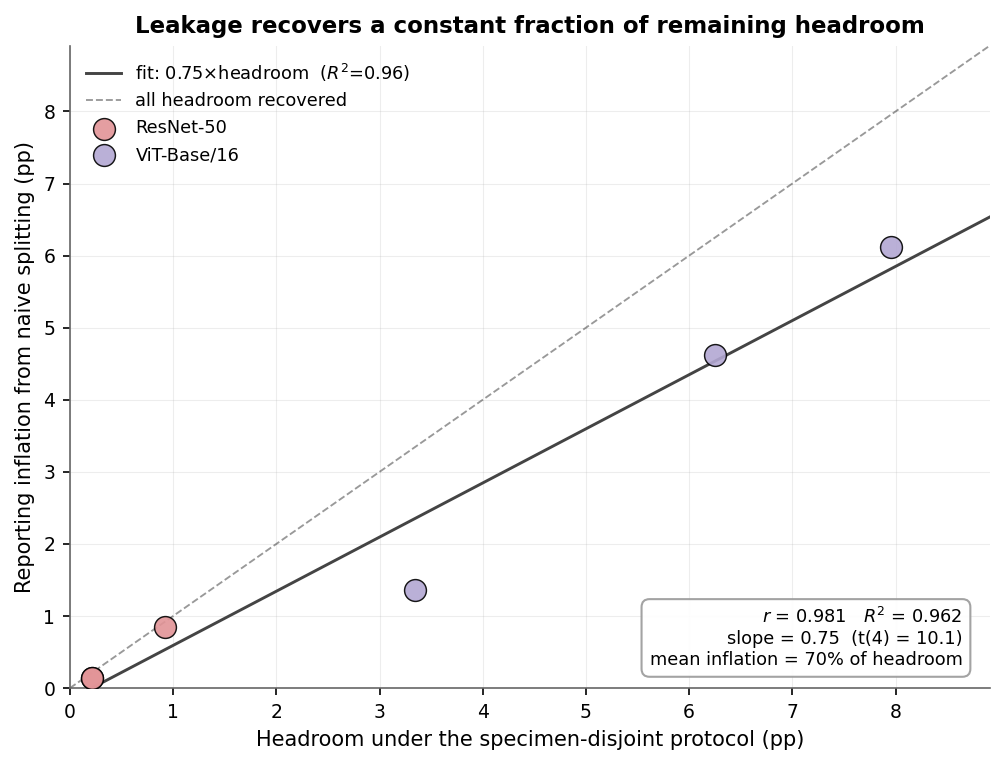

    model  seed  group  headroom  inflation  pct_of_headroom
 ResNet50     7 0.9979    0.0021     0.0014           0.6683
 ResNet50    42 0.9908    0.0092     0.0085           0.9235
 ResNet50   123 0.9979    0.0021     0.0014           0.6683
ViTBase16     7 0.9375    0.0625     0.0463           0.7399
ViTBase16    42 0.9666    0.0334     0.0136           0.4072
ViTBase16   123 0.9204    0.0796     0.0612           0.7690

Pooled n=6: r=0.9809, R^2=0.9622, slope=0.751, t(4)=10.09
Leakage recovers 70% of available headroom on average (range 41%-92%).

This is a stronger statement than the per-model effect sizes, and it is
the mechanism: a saturated benchmark has almost no headroom, so leakage
there is real but too small to measure.
--- table_headroom.tex ---
\begin{table}
\caption{Leakage-induced reporting inflation expressed against the headroom remaining under the specimen-disjoint protocol. Inflation scales with headroom rather than being a fixed offset, which is why a near-saturate

In [17]:
# ===== 16. Saturation mechanism: headroom vs leakage inflation =====
# THIS IS THE PAPER'S CENTRAL QUANTITATIVE CLAIM.
# Per-model t-tests on raw inflation are underpowered at n=3 (p=0.25 for ResNet,
# p=0.10 for ViT). But leakage does not add a fixed number of percentage points - it
# recovers a roughly constant FRACTION of whatever headroom is left. Pooling all runs
# from both architectures against headroom gives a far stronger and more interpretable
# relationship, and explains directly why a ResNet-only ablation on a saturated
# benchmark finds nothing: 75% of 0.2 pp is invisible.
abl_runs_path = Path(P_ABLATION)/'ablation_runs.csv'
if abl_runs_path.exists():
    ar = pd.read_csv(abl_runs_path)
    piv = ar.pivot_table(index=['model','seed'], columns='condition',
                         values='own_test_acc').reset_index()
    if {'naive','group'}.issubset(piv.columns):
        piv['headroom']  = 1.0 - piv['group']
        piv['inflation'] = piv['naive'] - piv['group']
        x,y = piv.headroom.values, piv.inflation.values
        n=len(x)
        r_ = np.corrcoef(x,y)[0,1] if n>2 else float('nan')
        sl,ic = np.polyfit(x,y,1) if n>1 else (np.nan,np.nan)
        ss_res=np.sum((y-(sl*x+ic))**2); ss_tot=np.sum((y-y.mean())**2)
        r2 = 1-ss_res/ss_tot if ss_tot>0 else float('nan')
        tstat = r_*np.sqrt((n-2)/(1-r_**2)) if n>2 and abs(r_)<1 else float('nan')

        fig,ax=plt.subplots(figsize=(6.8,5.2))
        xs=np.linspace(0, x.max()*1.12, 100)
        ax.plot(100*xs, 100*(sl*xs+ic), color='#444', lw=1.4, zorder=2,
                label=f'fit: {sl:.2f}$\\times$headroom  ($R^2$={r2:.2f})')
        ax.plot([0,100*x.max()*1.12],[0,100*x.max()*1.12],'k--',lw=.9,alpha=.4,zorder=1,
                label='all headroom recovered')
        for m in piv.model.unique():
            d=piv[piv.model==m]
            ax.scatter(100*d.headroom, 100*d.inflation, s=110, alpha=.9,
                       color=PAL.get(m,'gray'), edgecolor='k', lw=.7,
                       label=NAT.get(m,m), zorder=3)
        ax.set_xlabel('Headroom under the specimen-disjoint protocol (pp)')
        ax.set_ylabel('Reporting inflation from naive splitting (pp)')
        ax.set_title('Leakage recovers a constant fraction of remaining headroom')
        ax.legend(fontsize=8.5, loc='upper left')
        ax.set_xlim(0,100*x.max()*1.12); ax.set_ylim(0,100*x.max()*1.12)
        txt=(f'$r$ = {r_:.3f}   $R^2$ = {r2:.3f}\n'
             f'slope = {sl:.2f}  (t({n-2}) = {tstat:.1f})\n'
             f'mean inflation = {np.mean(y/x):.0%} of headroom')
        ax.text(.97,.03,txt,transform=ax.transAxes,ha='right',va='bottom',fontsize=8.5,
                bbox=dict(boxstyle='round,pad=0.45',fc='white',ec='#999',alpha=.9))
        plt.tight_layout(); save_fig(fig,'fig_headroom_vs_inflation'); plt.show()

        piv['pct_of_headroom']=(piv.inflation/piv.headroom)
        piv.to_csv(OUT_DIR/'headroom_vs_inflation.csv',index=False)
        print(piv[['model','seed','group','headroom','inflation','pct_of_headroom']].round(4).to_string(index=False))
        print(f'\nPooled n={n}: r={r_:.4f}, R^2={r2:.4f}, slope={sl:.3f}, t({n-2})={tstat:.2f}')
        print(f'Leakage recovers {np.mean(y/x):.0%} of available headroom on average '
              f'(range {np.min(y/x):.0%}-{np.max(y/x):.0%}).')
        print('\nThis is a stronger statement than the per-model effect sizes, and it is')
        print('the mechanism: a saturated benchmark has almost no headroom, so leakage')
        print('there is real but too small to measure.')
        emit(piv.assign(Model=[NAT.get(m,m) for m in piv.model],
                        Headroom=(100*piv.headroom).round(2),
                        Inflation=(100*piv.inflation).round(2),
                        Pct=(100*piv.pct_of_headroom).round(0))[['Model','seed','Headroom','Inflation','Pct']]
                  .rename(columns={'seed':'Seed','Headroom':'Headroom (pp)',
                                   'Inflation':'Inflation (pp)','Pct':'\\% of headroom'}),
             'table_headroom', 'Leakage-induced reporting inflation expressed against the '
             'headroom remaining under the specimen-disjoint protocol. Inflation scales with '
             'headroom rather than being a fixed offset, which is why a near-saturated model '
             'shows almost no measurable leakage effect.',
             'tab:headroom', col='lrrrr')
    else:
        print('ablation_runs.csv lacks both conditions - skipped')
else:
    print('No ablation_runs.csv - run the multi-seed NB02 first.')

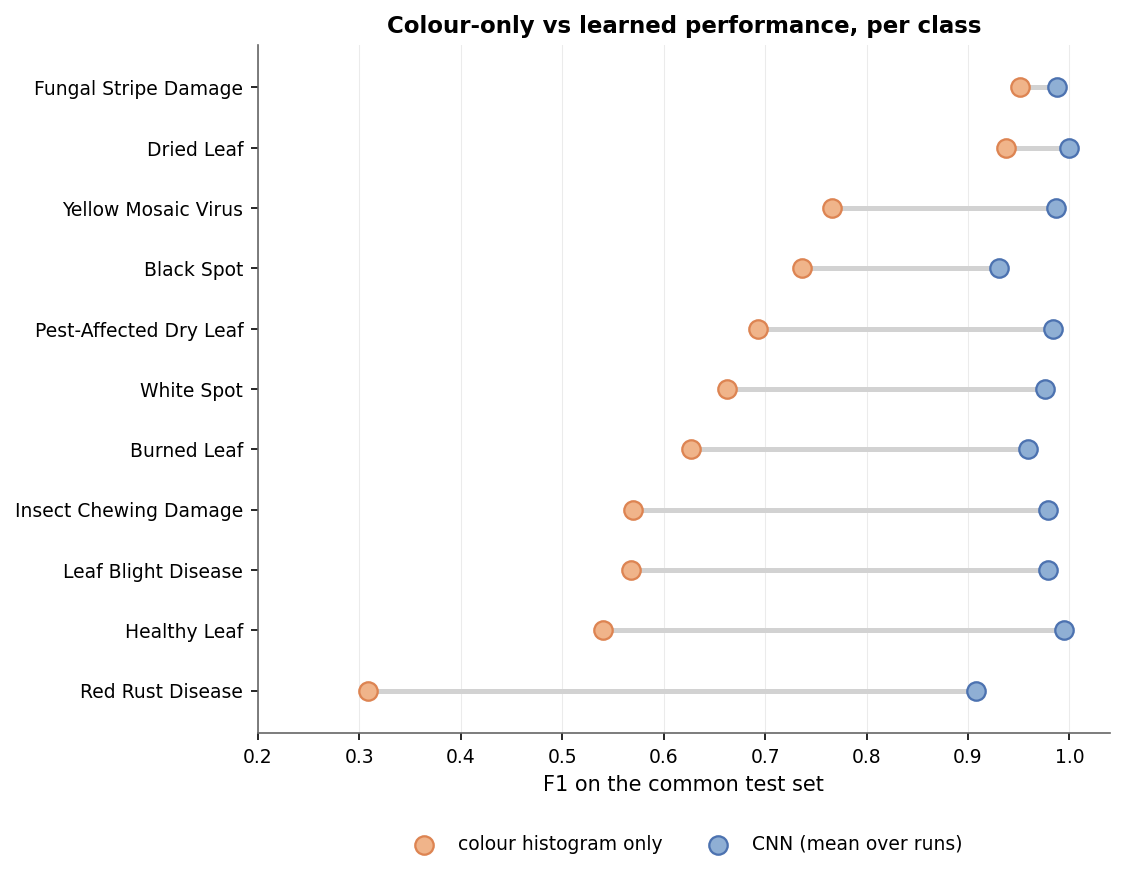

                 class  colour_only_f1  cnn_f1   gap
      Red Rust Disease           0.308   0.908 0.600
          Healthy Leaf           0.541   0.995 0.454
   Leaf Blight Disease           0.568   0.979 0.411
 Insect Chewing Damage           0.569   0.979 0.410
           Burned Leaf           0.627   0.960 0.332
            White Spot           0.662   0.976 0.314
Pest-Affected Dry Leaf           0.693   0.984 0.291
            Black Spot           0.736   0.931 0.195
   Yellow Mosaic Virus           0.766   0.987 0.221
            Dried Leaf           0.938   0.999 0.061
  Fungal Stripe Damage           0.951   0.988 0.037

A short bar = colour alone nearly solves that class.
A long bar  = the CNN is using something beyond colour.
--- table_colour_reliance.tex ---
\begin{table}
\caption{Per-class F1 from a colour histogram baseline versus the trained CNNs on the common test set. Colour reliance is strongly class-dependent.}
\label{tab:colour_reliance}
\begin{tabular}{lrrr}
\toprul

In [18]:
# ===== 17. Which classes are solvable by colour alone? =====
# Concern #8 asked whether colour/background is doing more work than expected. The
# aggregate answer is in table_shortcut_external, but the per-class picture is the
# informative one: colour reliance is highly class-specific, not uniform.
knn_p = P_SHORT/'knn_color_per_class.json'
if knn_p.exists() and pcf and CLASSES:
    knn_j = json.load(open(knn_p))
    kf = knn_j.get('per_class_f1', {})
    md_={}
    for tag,v in pcf.items():
        m=tag.rsplit('_seed',1)[0]; md_.setdefault(m,[]).append(v)
    cnn_mean = np.mean([np.mean(v,axis=0) for v in md_.values()],axis=0)  # mean over models+seeds
    rows=[{'class':c,'colour_only_f1':kf.get(c,np.nan),'cnn_f1':cnn_mean[i]}
          for i,c in enumerate(CLASSES) if c in kf]
    cr=pd.DataFrame(rows).sort_values('colour_only_f1')
    fig,ax=plt.subplots(figsize=(7.6,0.34*len(cr)+2.2))
    y=np.arange(len(cr))
    ax.hlines(y, cr.colour_only_f1, cr.cnn_f1, color='#d2d2d2', lw=2.4, zorder=1)
    ax.scatter(cr.colour_only_f1, y, s=78, color='#F0B48A', edgecolor='#DD8452', lw=1.1,
               label='colour histogram only', zorder=3)
    ax.scatter(cr.cnn_f1, y, s=78, color='#8FAFD4', edgecolor='#4C72B0', lw=1.1,
               label='CNN (mean over runs)', zorder=3)
    ax.set_yticks(y); ax.set_yticklabels(cr['class'], fontsize=9)
    ax.set_xlabel('F1 on the common test set'); ax.set_xlim(0.20,1.04)
    ax.set_ylim(-0.7,len(cr)-0.3); ax.grid(axis='y',visible=False)
    ax.set_title('Colour-only vs learned performance, per class')
    ax.legend(fontsize=9, loc='lower center', bbox_to_anchor=(0.5,-0.20),
              ncol=2); ax.grid(axis='x', alpha=.25)
    plt.tight_layout(); save_fig(fig,'fig_colour_reliance_per_class'); plt.show()
    cr['gap']=cr.cnn_f1-cr.colour_only_f1
    cr.to_csv(OUT_DIR/'colour_reliance_per_class.csv',index=False)
    print(cr.round(3).to_string(index=False))
    print('\nA short bar = colour alone nearly solves that class.')
    print('A long bar  = the CNN is using something beyond colour.')
    emit(cr.rename(columns={'class':'Class','colour_only_f1':'Colour-only F1',
                            'cnn_f1':'CNN F1','gap':'Gap'}),
         'table_colour_reliance',
         'Per-class F1 from a colour histogram baseline versus the trained CNNs on the '
         'common test set. Colour reliance is strongly class-dependent.',
         'tab:colour_reliance', col='lrrr')
else:
    print('Need NB05 knn_color_per_class.json and NB03/NB04 per-class F1 - skipped.')